# Methoden en Technieken -- Blok 2

## Datapunt 2b,

In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en
technische requirements** op.
- B1: Je **verkent en prepareert een dataset voor het trainen en testen van een AI-model** en
kan de voor- en nadelen van het gebruik van een bestaande dataset onderbouwen, rekening
houdend met technische en ethische randvoorwaarden.
- B2: Je **stelt op basis van requirements en data een geschikte architectuur voor een AI-
oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld machine learning, deep learning, kennisrepresentatie, computer vision** en natural language
processing.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model volgens een iteratief en systematisch
proces**.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability,
explainability, **model complexity** en resource demand.

Dit is een individuele opdracht. Het is toegestaan met elkaar de opdracht te bespreken, maar iedereen schrijft zijn eigen code en antwoorden. Mocht je code van het internet hebben overgenomen/aangepast, vermeld dan de bron in het commentaar. Het gebruik van generatieve AI (Chat-GPT, etc...) is *alleen* toegestaan bij de voorbereiding op de opdracht. Denk hierbj aan activiteiten zoals brainstormen, of het maken van een plan. Het is niet toegestaan code of tekst van generative AI over te nemen. (Level 2 van de AI Assessment Scale)

Als je gebruik maakt van bronnen om jouw keuzes te verantwoorden willen we bij deze opdracht het volgende zien:
- De bronverwijzing (online link indien beschikbaar)
- De uitspraak die jij doet
- Paragraafnummer uit de bron waar je deze uitspraak op baseert
- Een letterlijke quote uit de bron waar je jouw uitspraak op baseert

(Merk op: dit is veel uitgebreider dan wat er meestal in rapporten verwacht wordt, en is puur bedoeld te controleren of de student correct kan verwijzen.)

Voorbeeld:
> De laatste jaren zijn GANs veel minder populair als generatieve modellen [1] (H17: "(GANs) have gradually fallen out of fashion in recent years and have been all but replaced by diffusion models")
>
> ...
>
> Bronnenlijst:
>
> [1] F. Chollet and M. Watson, Deep Learning in Python, 3rd edition, Manning, 2025. 

https://github.com/fchollet/deep-learning-with-python-notebooks/blob/master/chapter17_image-generation.ipynb

base model

## De opdracht

De volgende code laadt de data in. Dit is een gedeeltelijk gelabelde variant van de MNIST dataset

In [4]:
#| include: false

# Standard library
import os
# import pickle

# Environment configuration
os.environ["KERAS_BACKEND"] = "torch"

# Core numerical and ML libraries
import numpy as np
import torch
# import keras
# from keras import layers, Model, Input, optimizers

# # Visualization
# import matplotlib.pyplot as plt
# import seaborn as sns
# import visualkeras

# # Scikit-learn utilities
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, classification_report

# # 3d visualisation
# from mpl_toolkits.mplot3d import Axes3D
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
# from sklearn.feature_selection import mutual_info_classif
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE
    

# Hardware check
if torch.cuda.is_available():
    print('Notebook gebruikt windows GPU')
elif torch.mps.is_available():
    print('Notebook gebruikt apple GPU')
else:
    print('Notebook gebruikt CPU')


# # Data loading
# with open('data_2b_new.pkl', 'rb') as file:
#     x_labeled, y_labeled, x_unlabeled = pickle.load(file)


Notebook gebruikt CPU


## Helper functions for iterations (save, load, plot)

In [ ]:
def _resolve_history_dict(history_or_dict):
    if history_or_dict is None:
        raise ValueError("history_or_dict is None.")
    # Keras History object
    hist = getattr(history_or_dict, 'history', None)
    if isinstance(hist, dict):
        return hist
    # Already a dict-like
    if isinstance(history_or_dict, dict):
        return history_or_dict
    raise TypeError("Expected a Keras History or dict of lists.")


def plot_training_curves(history, title_prefix=None):
    h = _resolve_history_dict(history)
    keys = set(h.keys())

    # Primary pairs
    pairs = []
    if 'loss' in keys or 'val_loss' in keys:
        pairs.append(('loss', 'val_loss'))

    # Accuracy candidates
    acc_candidates = ['accuracy', 'sparse_categorical_accuracy', 'categorical_accuracy', 'binary_accuracy']
    acc_key = next((k for k in acc_candidates if k in keys), None)
    if acc_key:
        pairs.append((acc_key, f'val_{acc_key}'))

    # Extra VAE metrics if present
    for base in ['reconstruction_loss', 'kl_loss']:
        train_k = base
        val_k = f'val_{base}'
        if train_k in keys or val_k in keys:
            pairs.append((train_k, val_k))

    if not pairs:
        # Fallback: plot any available series
        for k in sorted(keys):
            vk = f'val_{k}'
            pairs.append((k, vk))

    n = len(pairs)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 4))
    if n == 1:
        axes = [axes]

    # Determine epochs from first available series length
    ref_series = next((h[p[0]] for p in pairs if p[0] in h and isinstance(h[p[0]], (list, tuple)) and len(h[p[0]])>0), None)
    if ref_series is None:
        ref_series = next((h[p[1]] for p in pairs if p[1] in h and isinstance(h[p[1]], (list, tuple)) and len(h[p[1]])>0), None)
    num_epochs = len(ref_series) if ref_series is not None else None
    epochs = range(1, (num_epochs or 0) + 1)

    for ax, (train_k, val_k) in zip(axes, pairs):
        plotted = False
        if train_k in h and isinstance(h[train_k], (list, tuple)):
            ax.plot(epochs, h[train_k], label=f"Train {train_k}")
            plotted = True
        if val_k in h and isinstance(h[val_k], (list, tuple)):
            ax.plot(epochs, h[val_k], label=f"Val {train_k}")
            plotted = True
        ax.set_title(f"{title_prefix+' - ' if title_prefix else ''}{train_k}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(train_k)
        ax.grid(True, alpha=0.3)
        if plotted:
            ax.legend()
        else:
            ax.set_visible(False)

    plt.tight_layout()
    plt.show()


def save_model_and_history(model, history, name='model', models_dir='models', history_dir='history'):
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(history_dir, exist_ok=True)
    weights_path = os.path.join(models_dir, f"{name}.weights.h5")
    hist_path = os.path.join(history_dir, f"{name}_hist.pkl")

    # Save weights
    model.save_weights(weights_path)

    # Save history dict
    h = _resolve_history_dict(history)
    with open(hist_path, 'wb') as f:
        pickle.dump(h, f)

    print(f"Saved weights → {weights_path}")
    print(f"Saved history → {hist_path}")
    return {"weights": weights_path, "history": hist_path}


def load_vae_weights(vae, name, models_dir='models'):
    weights_path = os.path.join(models_dir, f"{name}.weights.h5")
    if not os.path.exists(weights_path):
        print(f"Warning: VAE weights not found at {weights_path}")
        return False
    vae.load_weights(weights_path)
    print(f"Loaded VAE weights from: {weights_path}")
    return True

def load_history(name, models_dir='history'):
    hist_path = os.path.join(models_dir, f"{name}_hist.pkl")
    if not os.path.exists(hist_path):
        print(f"Warning: History not found at {hist_path}")
        return None
    with open(hist_path, 'rb') as f:
        history = pickle.load(f)
    print(f"Loaded history from: {hist_path}")
    return history

def plot_vae_reconstructions(vae, x_data, n_examples=2, start_idx=1):
    # Encode and decode
    latent, _ = vae.encoder.predict(x_data, verbose=0)
    reconstructed = vae.decoder.predict(latent, verbose=0)
    
    # Create grid: n_examples rows, 2 columns (original, reconstructed)
    fig, axes = plt.subplots(n_examples, 2, figsize=(6, 3*n_examples))
    
    # Handle single example case
    if n_examples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(n_examples):
        idx = start_idx + i
        
        # Original image
        axes[i, 0].imshow(1 - x_data[idx].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f'MNIST {idx} - origineel')
        
        # Reconstructed image
        axes[i, 1].imshow(1 - reconstructed[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
        axes[i, 1].axis('off')
        axes[i, 1].set_title(f'MNIST {idx} - getransformeerd')
    
    plt.tight_layout()
    plt.show()

def analyze_active_dimensions(vae, x_data, threshold=0.01):
    # Encode data
    z_mean, z_log_var = vae.encoder.predict(x_data, verbose=0)
    
    # Calculate variance per dimension
    variances = np.var(z_mean, axis=0)
    
    # Identify active dimensions
    active_mask = variances > threshold
    n_active = np.sum(active_mask)
    active_dims = np.where(active_mask)[0]
    
    # Plot variance per dimension
    latent_dim = z_mean.shape[1]
    plt.figure(figsize=(10, 4))
    plt.bar(range(latent_dim), variances, color=['green' if v > threshold else 'lightgray' for v in variances])
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold ({threshold})')
    plt.xlabel('Latent Dimension')
    plt.ylabel('Variance')
    plt.title(f'Active Dimensions: {n_active}/{latent_dim}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Active dimensions: {n_active}/{latent_dim}")
    print(f"Active indices: {active_dims.tolist()}")
    print(f"Variances: {variances}")
    
    return {
        'variances': variances,
        'active_dims': active_dims,
        'n_active': n_active
    }


def plot_latent_space(vae, x_data, y_labels, title='Latent Space Visualization', method='pca'):
    # Encode data
    z_mean, z_log_var = vae.encoder.predict(x_data, verbose=0)
    latent_dim = z_mean.shape[1]
    
    # Prepare data for plotting
    if latent_dim == 2:
        z_plot = z_mean
        x_label, y_label = 'Latent Dim 0', 'Latent Dim 1'
    elif latent_dim > 2:
        if method == 'pca':
            reducer = PCA(n_components=2, random_state=42)
            z_plot = reducer.fit_transform(z_mean)
            var_explained = reducer.explained_variance_ratio_
            x_label = f'PC1 ({var_explained[0]:.1%} var)'
            y_label = f'PC2 ({var_explained[1]:.1%} var)'
        elif method == 'tsne':
            reducer = TSNE(n_components=2, random_state=42, perplexity=min(30, len(x_data)-1))
            z_plot = reducer.fit_transform(z_mean)
            x_label, y_label = 't-SNE 1', 't-SNE 2'
        else:
            raise ValueError(f"Unknown method: {method}. Use 'pca' or 'tsne'.")
        title = f"{title} ({method.upper()}: {latent_dim}D → 2D)"
    else:
        raise ValueError(f"Latent dimension must be >= 2, got {latent_dim}")
    
    # Create scatter plot colored by class
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(z_plot[:, 0], z_plot[:, 1], 
                         c=y_labels, cmap='tab10', 
                         alpha=0.6, edgecolors='k', linewidth=0.5)
    plt.colorbar(scatter, label='Class')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return z_mean

In [11]:
print(f"Observations — labeled: {x_labeled.shape[0]}, unlabeled: {x_unlabeled.shape[0]}")

Observations — labeled: 250, unlabeled: 69750


## Split strategy

De dataset is opgesplitst volgens een 80/10/10-verdeling voor respectievelijk de trainings-, validatie- en testset. Deze keuze is gemaakt vanwege de beperkte hoeveelheid beschikbare data, waarbij het maximaliseren van de trainingsdata essentieel is om het model effectief te kunnen leren. Met deze verdeling resulteert de split in respectievelijk 200, 25 en 25 voorbeelden.

Daarnaast is gebruikgemaakt van een gestratificeerde split, zodat elke subset representatief blijft voor de oorspronkelijke klasseverdeling. Concreet betekent dit dat zowel de validatie- als testset minimaal twee voorbeelden per cijfer bevatten. Dit is belangrijk om betrouwbaar te kunnen evalueren of het model in staat is alle tien de verschillende cijfers te herkennen en te generaliseren over alle klassen.

Hoewel stratificatie formeel kan worden gezien als een lichte vorm van data leakage, wordt deze keuze hier bewust gemaakt. De MNIST-dataset is een gevestigde en volledig gelabelde benchmark, waarbij het aantal en type klassen bekend is. In deze context weegt het voordeel van voldoende klasse-representatie in alle splits zwaarder dan het theoretische nadeel, omdat het primaire doel is om consistente en interpreteerbare evaluatieresultaten te verkrijgen en het kleine beetje labeled data zo goed mogelijk te benutten.

In [20]:
# Train/Val/Test split for labeled data (no test labels kept in memory)
RANDOM_SEED = 42

# First split: training set (80%) and temp set for val+test (20%)
x_train, x_temp, y_train, y_temp = train_test_split(
    x_labeled,
    y_labeled,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_labeled
)

# Second split: split temp evenly into validation and test (10% each)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp
)

# Print shapes for visibility
print("Split complete:")
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_val:", x_val.shape, "y_val:", y_val.shape)
print("x_test (held out):", x_test.shape)

# Safety: remove test references to avoid accidental use

# del x_test, y_test


Split complete:
x_train: (200, 28, 28, 1) y_train: (200,)
x_val: (25, 28, 28, 1) y_val: (25,)
x_test (held out): (25, 28, 28, 1)


De opdracht is om een *semi-supervised* model te trainen dat deze data zo goed mogelijk (rekening houdend met tijd en beschikbare hardware) kan classificeren. De enige voorwaarde is dat dit model gebruik moet maken van een *variational auto encoder* die unsupervised getrained is op deze data. Zie onder andere lessen 11, 12 en 13 van M&T blok 2 voor inspiratie.

Je zult waarschijnlijk meerdere iteraties op beide het *unsupervised* (de VAE) gedeelte en het *supervised* gedeelte van je model doorlopen. Zorg dat deze iteraties duidelijk in je notebook beschreven staan, wis ze niet!

## Deel 1

Voer een data preparatie/verkenning uit, leg kort uit wat je opvalt. Stel op basis hiervan een korte lijst van *requirements* op waar je model aan moet voldoen.

### Data exploration

x_train: (200, 28, 28, 1) uint8
y_train: (200,) uint8
x_unlabeled: (69750, 28, 28, 1) float32
x_train pixels -> min: 0.000, max: 1.000, mean: 0.130, std: 0.307
x_unlabeled pixels -> min: 0.000, max: 1.000, mean: 0.131, std: 0.308
Train labels gevonden: [0 1 2 3 4 5 6 7 8 9]
Train per-klasse aantallen: {np.uint8(0): np.int64(24), np.uint8(1): np.int64(24), np.uint8(2): np.int64(15), np.uint8(3): np.int64(17), np.uint8(4): np.int64(16), np.uint8(5): np.int64(30), np.uint8(6): np.int64(16), np.uint8(7): np.int64(19), np.uint8(8): np.int64(17), np.uint8(9): np.int64(22)}


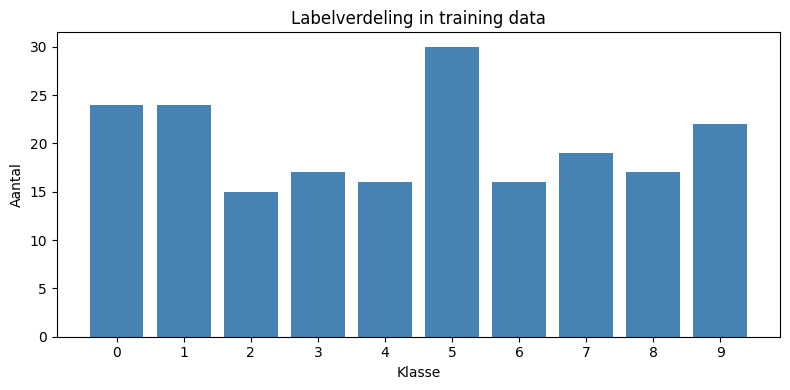

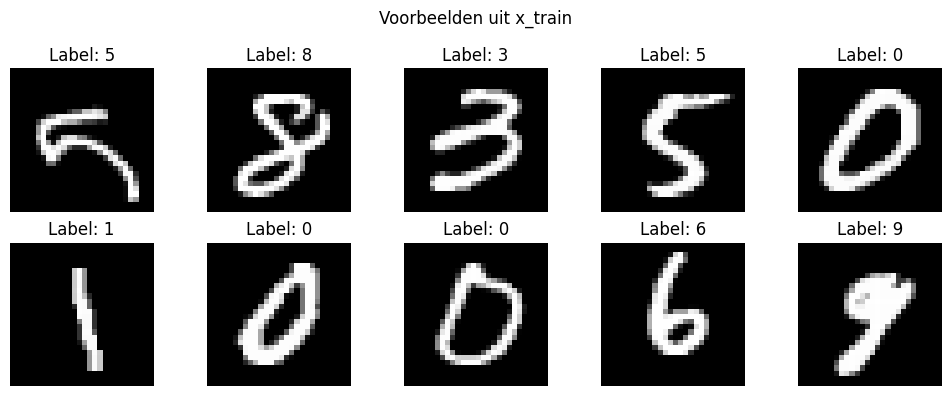

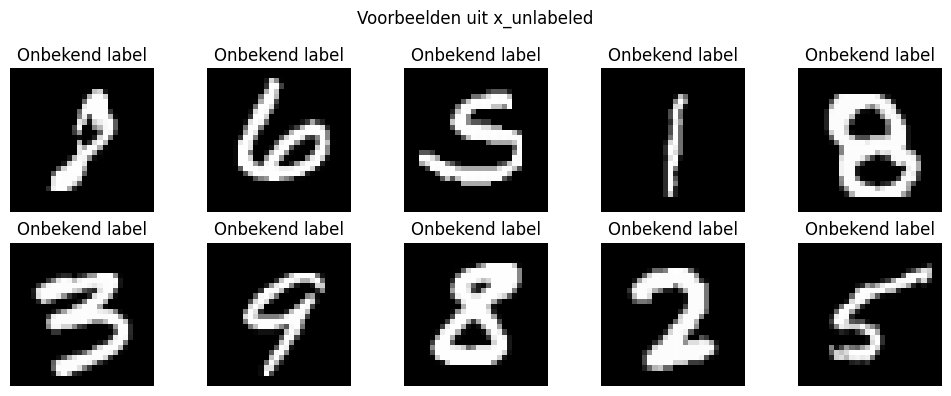

In [21]:
# Data-exploratie voor Datapunt 2b (MNIST variant, deels gelabeld)
# Basisinformatie (alleen TRAIN + unlabeled; geen VAL/TEST)
print("x_train:", x_train.shape, y_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_unlabeled:", x_unlabeled.shape, x_unlabeled.dtype)

# Stats helper

def describe_pixels(name, arr):
    arr_min = float(np.min(arr))
    arr_max = float(np.max(arr))
    arr_mean = float(np.mean(arr))
    arr_std = float(np.std(arr))
    print(f"{name} pixels -> min: {arr_min:.3f}, max: {arr_max:.3f}, mean: {arr_mean:.3f}, std: {arr_std:.3f}")

# Alleen TRAIN en UNLABELED verkennen (geen VAL/TEST)
describe_pixels("x_train", x_train)
describe_pixels("x_unlabeled", x_unlabeled)

# Labelverdeling (alleen TRAIN)
unique_labels, label_counts = np.unique(y_train, return_counts=True)
print("Train labels gevonden:", unique_labels)
print("Train per-klasse aantallen:", dict(zip(unique_labels, label_counts)))

plt.figure(figsize=(8,4))
plt.bar(unique_labels, label_counts, color="steelblue")
plt.title("Labelverdeling in training data")
plt.xlabel("Klasse")
plt.ylabel("Aantal")
plt.xticks(unique_labels)
plt.tight_layout()
plt.show()

# Enkele voorbeeldafbeeldingen (TRAIN)
n_show = 10
rng = np.random.default_rng(42)
idx_l = rng.choice(len(x_train), size=n_show, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for ax, i in zip(axes.flat, idx_l):
    img = x_train[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {int(y_train[i])}")
    ax.axis("off")
fig.suptitle("Voorbeelden uit x_train")
plt.tight_layout()
plt.show()

# Enkele voorbeeldafbeeldingen (ONGELABELD)
idx_u = rng.choice(len(x_unlabeled), size=n_show, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for ax, i in zip(axes.flat, idx_u):
    img = x_unlabeled[i]
    ax.imshow(img, cmap="gray")
    ax.set_title("Onbekend label")
    ax.axis("off")
fig.suptitle("Voorbeelden uit x_unlabeled")
plt.tight_layout()
plt.show()

Tijdens de data-exploratie is vastgesteld dat de gelabelde trainingsset bestaat uit 200 MNIST-afbeeldingen van 28×28 pixels met alle tien cijfers (0–9) aanwezig. Daarnaast is een grote ongelabelde set van 69.750 afbeeldingen beschikbaar, wat past bij de semi-supervised opzet.

De pixelwaarden zijn genormaliseerd naar het bereik [0, 1]. De gelabelde en ongelabelde data vertonen vrijwel identieke statistieken (gemiddelde ≈ 0,13 en standaarddeviatie ≈ 0,31), wat wijst op een consistente datadistributie.

De klasseverdeling in de trainingsdata is licht ongelijk, maar elke klasse is voldoende vertegenwoordigd met 15 tot 30 voorbeelden per cijfer, zoals te zien in de verdelingsgrafiek.

### Requirements



**Functionele en technische requirements**

1. Het model moet een semi-supervised leeropzet hebben waarbij zowel gelabelde als ongelabelde MNIST-data wordt gebruikt.
2. Het model moet een variational auto encoder (VAE) bevatten die unsupervised wordt getraind op de ongelabelde samples.
3. De encoder van de VAE moet latente representaties leren die geschikt zijn voor classificatie, waarbij de classificatie uitsluitend wordt uitgevoerd op basis van de encoder-output.
4. De VAE wordt primair geoptimaliseerd op de kwaliteit en scheidbaarheid van de latente representaties ten behoeve van de classificatietaak, waarbij de reconstructiedoelstelling uitsluitend dient als ondersteunend unsupervised leersignaal.
5. Het classificatiemodel mag uitsluitend gebruikmaken van de latente representaties afkomstig van de VAE-encoder en mag geen directe toegang hebben tot de ruwe input images.
6. Het model moet iteratief worden ontwikkeld waarbij zowel het unsupervised VAE-gedeelte als het supervised classificatiegedeelte meerdere verbeterstappen doorlopen, en deze iteraties zichtbaar en beargumenteerd worden vastgelegd in de notebook.
7. Het uiteindelijke semi-supervised model moet aantoonbaar beter presteren dan een baseline model dat uitsluitend supervised is getraind op de gelabelde data, gemeten met een vooraf vastgelegde performance metric zoals accuracy.
8. Het model moet geschikt zijn voor classificatie van alle tien MNIST-klassen, waarbij voor geen enkele klasse een accuracy lager dan 50% wordt behaald.
9. Het leerzwaartepunt moet in de VAE-encoder liggen zodat de latente representatie optimaal wordt benut, terwijl de classificatiekop eenvoudig blijft om snelle hertraining en iteratie met nieuw gelabelde data mogelijk te maken zonder hertraining van het volledige model.

**Complexiteit en resource requirements**

10. De architectuurcomplexiteit moet beperkt blijven waarbij de encoder, decoder en classifier elk maximaal één extra laag mogen bevatten ten opzichte van de baseline-architectuur.
11. De dimensionele grootte van de latente ruimte moet expliciet worden gekozen, gemotiveerd worden en zo klein mogelijk blijven zonder significante negatieve impact op de classificatieprestatie.
12. Het totaal aantal trainbare parameters moet beperkt blijven en mag slechts in beperkte mate groter zijn dan dat van de baseline, zodat training mogelijk is binnen redelijke tijd.

**Evaluatie en kwaliteitseisen**

13. De prestaties van het model moeten worden geëvalueerd aan de hand van erkende kwaliteitscriteria uit het vakgebied, waaronder ten minste classificatieprestatie en modelcomplexiteit.
14. Er moet een expliciete en onderbouwde afweging worden gemaakt tussen prestatieverbetering en toename in modelcomplexiteit, waarbij kleine prestatieverbeteringen met sterke complexiteitsgroei worden vermeden.

### Performance Measures & Metrics
Het doel van dit project is het bouwen van een model dat goed presteert op een semi-supervised classificatietaak. Daarom is de classificatieprestatie de belangrijkste evaluatiemaat, terwijl de metrics van de Variational Autoencoder (VAE) voornamelijk worden gebruikt om de kwaliteit en bruikbaarheid van de latente representaties te analyseren en te optimaliseren.

#### VAE loss en training stabiliteit

Voor de VAE worden de totale loss, de reconstruction loss en de KL-divergence loss gemonitord tijdens training. De reconstruction loss geeft aan in hoeverre de decoder in staat is om de invoer te reconstrueren vanuit de latente variabelen. De KL-loss meet hoeveel informatie de encoder daadwerkelijk opslaat in de latente ruimte ten opzichte van de gekozen prior. [1]*(1. Introduction: “The first term is (the KL divergence of the approximate posterior from the prior) acts as a regularizer, while the second term is an expected negative reconstruction error”)* Deze metrics worden gebruikt om te controleren of de VAE stabiel traint en om problemen zoals een te sterke bottleneck of posterior collapse te detecteren [2]*(1. Introduction: "Unfortunately, the quality and the number of the latent factors learned is directly controlled by the extent of a phenomenon known as posterior collapse, where the generative model learns to ignore a subset of the latent variables. Most existing work suggests that posterior collapse is caused by the KL-divergence term in the ELBO objective, which directly encourages the variational distribution to match the prior.")*. Daarnaast worden reconstructies visueel geanalyseerd om te verifiëren dat relevante structurele informatie behouden blijft.

#### Classifier-metrics

Aangezien classificatie het uiteindelijke doel is, wordt de performance van het volledige model primair geëvalueerd aan de hand van classificatie accuracy. Alle klassen zijn even belangrijk en fouten hebben gelijke kosten, waardoor aanvullende metrics zoals precision en recall niet noodzakelijk zijn. De loss van de classifier wordt gebruikt als ondersteunende maat om te signaleren of er sprake is van onder- of overfitting of een bottleneck tussen de latente ruimte en de classificatie head.

#### Analyse van de latente ruimte

Om de kwaliteit van de latente representaties te beoordelen, wordt het aantal actieve latente dimensies geanalyseerd door de variantie van de latente gemiddelden per dimensie te berekenen. Dimensies met een lage variantie worden als inactief beschouwd, omdat zij geen relevante latente factoren representeren. Deze analyse geeft inzicht in de effectieve dimensionaliteit van de latente ruimte en maakt het mogelijk om overbodige latente dimensies te identificeren.

Dit is een geschikte aanpak, aangezien ARD-VAE: A Statistical Formulation to Find the Relevant Latent Dimensions of Variational Autoencoders expliciet stelt dat de relevantie van latente dimensies kan worden bepaald op basis van hun variantie [3] *(1. Introduction “The variance (α⁻¹) along the latent axes is used to determine the relevant latent factors required to represent a dataset, such that the unwanted latent variables, through training, obtain very low variance.")*

De drempel voor actieve dimensies wordt empirisch bepaald op basis van de scheiding in de variantieverdeling, waarbij de kleinste dimensie met duidelijke variatie als grens wordt genomen. Dit is noodzakelijk, aangezien ARD-VAE expliciet stelt dat het kiezen van een algemene drempelwaarde voor relevante latente dimensies niet triviaal is en contextafhankelijk blijft [3] *(H3.4: "Thus, the choice of a threshold … is non-trivial.")*.

Daarnaast wordt de latente ruimte gevisualiseerd in twee dimensies met behulp van PCA. Door deze projectie te kleuren op basis van klasselabels kan op een kwalitatieve manier worden onderzocht in hoeverre de klassen scheidbaar zijn in de latente representatie. Deze visualisatie is met name relevant voor de downstream classificatietaak, omdat een beter gestructureerde latente ruimte doorgaans leidt tot eenvoudigere scheidbaarheid voor een classifier. Tegelijkertijd wordt benadrukt dat een tweedimensionale projectie slechts een vereenvoudigde weergave is van een hoog-dimensionale latente ruimte en daarom niet kan worden gebruikt als definitief bewijs voor disentanglement, maar uitsluitend dient als visueel hulpmiddel ter ondersteuning van de kwantitatieve evaluatie.

Het gebruik van visuele inspectie als aanvullende analysemethode voor latente representaties wordt ondersteund door de literatuur. Zo stellen Higgins et al. in β-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework expliciet dat visuele analyse kan worden ingezet om inzicht te verkrijgen in de kwaliteit van geleerde representaties in onsupervised settings [4]*(2. β-VAE FRAMEWORK DERIVATION "The optimal value of β can be estimated using either our proposed disentanglement metric or through visual inspection heuristics.")*



## Deel 2

Maak een eerste model en verbeter dit via een iteratief en systematisch proces.

### Sampler & VAE architecture

In [22]:
class Sampler(keras.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator()
        self.built = True

    def call(self, z_mean, z_log_var):
        batch_size = keras.ops.shape(z_mean)[0]
        z_size = keras.ops.shape(z_mean)[1]
        epsilon = keras.random.normal(
            (batch_size, z_size), seed=self.seed_generator
        )
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon
    
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=None, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.sampler = Sampler()

        # beta handling
        self.beta = beta

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        return self.encoder(inputs)

    def compute_loss(self, x, y, y_pred, sample_weight=None, training=True):
        z_mean, z_log_var = y_pred
        reconstruction = self.decoder(self.sampler(z_mean, z_log_var))

        reconstruction_loss = keras.ops.mean(
            keras.ops.sum(
                keras.ops.binary_crossentropy(x, reconstruction), axis=(1, 2)
            )
        )

        kl_loss = -0.5 * (
            1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var)
        )
        kl_loss = keras.ops.mean(kl_loss)

        # apply beta only if provided
        if self.beta is not None:
            total_loss = reconstruction_loss + self.beta * kl_loss
        else:
            total_loss = reconstruction_loss + kl_loss

        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return total_loss

## Base model 

Als baseline is gekozen voor een Variational Autoencoder (VAE) zoals gepresenteerd in Les 13 van Robert Nolet. Deze structuur is gebaseerd op de code beschikbaar van Keras [5] De encoder van deze VAE wordt hergebruikt en uitgebreid met een eenvoudige classificatiekop die bestaat uit één volledig verbonden laag met een softmax-activatiefunctie, toegepast op de gemiddelde latente representatie 𝑧_mean. Deze combinatie is als referentiepunt voor alle volgende iteraties, waarbij verbeteringen aan zowel de VAE als de classificatieprestaties systematisch kunnen worden geëvalueerd.

De keuze voor een classificatiemodel met slechts één softmax-laag is bewust gemaakt om de classifier zo eenvoudig mogelijk te houden. Een dergelijke lineaire classificatiekop introduceert minimale extra modelcapaciteit en dwingt het model om discriminatieve informatie in de latente ruimte zelf te leren. Hierdoor kunnen veranderingen in classificatieprestatie makkelijker worden toegeschreven aan de kwaliteit van de door de VAE geleerde representaties, en niet aan extra complexiteit of expressiviteit in het classificatiemodel zoals ook beschreven wordt in werken over representation learning. [6] (H9.5: "In practice, we do this by saving the features learned (e.g. at regular intervals during training, to perform early stopping) and training a cheap classifier on top (such as a linear classifier)")

### VAE

In [23]:
latent_dim = 2

# Encoder
image_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="Decoder")


In [24]:
vae = VAE(encoder, decoder)

vae.compile(optimizer=keras.optimizers.Adam())

# Early stopping to allow many epochs without overfitting/leaking time
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, min_delta=1e-4, verbose=1
)

# Train VAE only on UNLABELED data; use an internal validation split
hist = vae.fit(
    x_unlabeled,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

# Save base VAE model and history using reusable function
paths = save_model_and_history(vae, hist, name='base_model')

Epoch 1/100
  7/436 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - kl_loss: 0.0048 - loss: 538.5386 - reconstruction_loss: 538.5339

c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\keras\src\backend\common\backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - kl_loss: 2.4958 - loss: 211.7602 - reconstruction_loss: 209.2614 - val_kl_loss: 2.5102 - val_loss: 191.2854 - val_reconstruction_loss: 188.7752
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - kl_loss: 2.4547 - loss: 187.4308 - reconstruction_loss: 184.9756 - val_kl_loss: 2.3898 - val_loss: 184.9386 - val_reconstruction_loss: 182.5490
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - kl_loss: 3.5542 - loss: 170.7447 - reconstruction_loss: 167.1899 - val_kl_loss: 3.8771 - val_loss: 164.2153 - val_reconstruction_loss: 160.3381
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - kl_loss: 3.8846 - loss: 161.1424 - reconstruction_loss: 157.2574 - val_kl_loss: 3.8700 - val_loss: 159.2340 - val_reconstruction_loss: 155.3638
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - kl_loss: 3.9685 - loss: 158.1922 - reconstruction_loss: 154.2232 - val_kl_loss: 3.8912 - val_loss: 157.3911 - val_reconstruction_loss: 153.4999
Epoch 6

### Base model (Classifier)

In [25]:
# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1550 - loss: 2.1137 - val_accuracy: 0.2000 - val_loss: 2.1454
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1600 - loss: 2.1117 - val_accuracy: 0.2000 - val_loss: 2.1436
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.1650 - loss: 2.1097 - val_accuracy: 0.2000 - val_loss: 2.1419
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1650 - loss: 2.1078 - val_accuracy: 0.2000 - val_loss: 2.1401
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1700 - loss: 2.1059 - val_accuracy: 0.2000 - val_loss: 2.1383
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1700 - loss: 2.1040 - val_accuracy: 0.1600 - val_loss: 2.1365
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1750 - loss: 2.1021 - val_accuracy: 0.1600 - val_loss: 2.1348
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1750 - loss: 2.1003 - val_accuracy: 0.1600 - v

### Evaluate base model

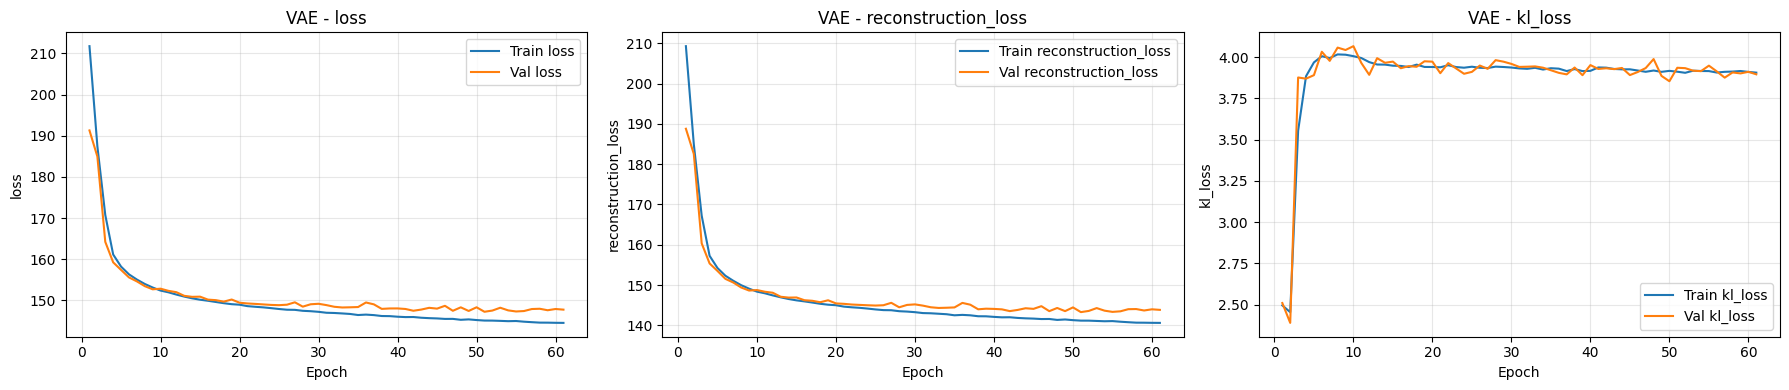

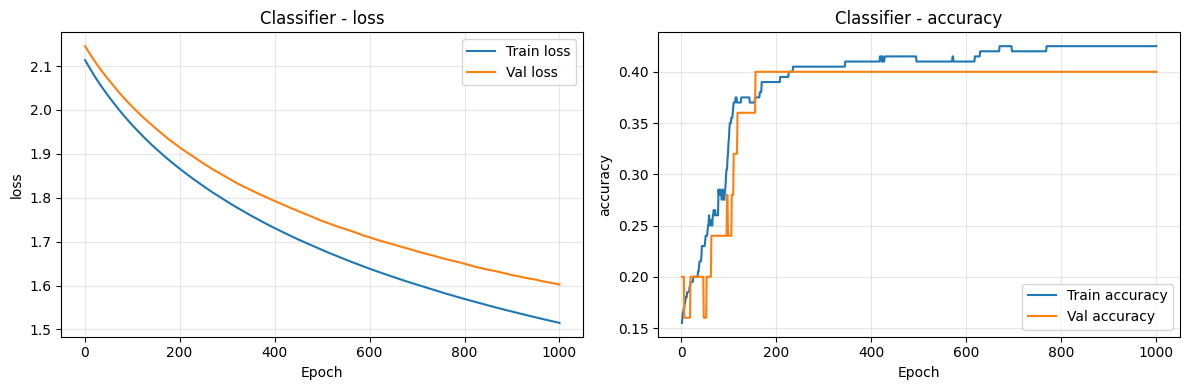

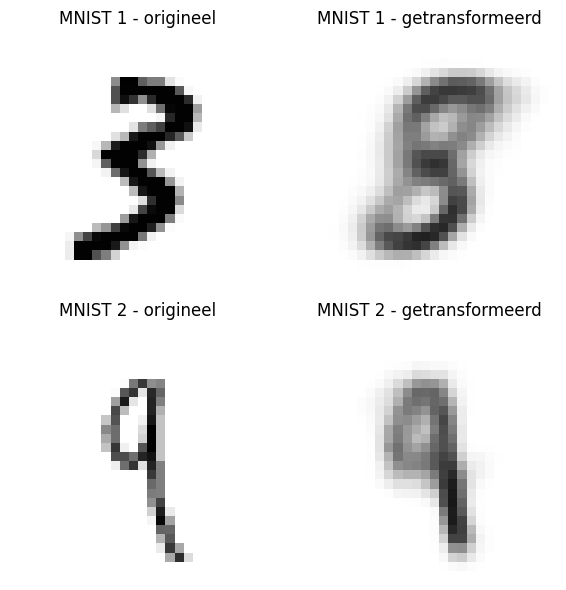

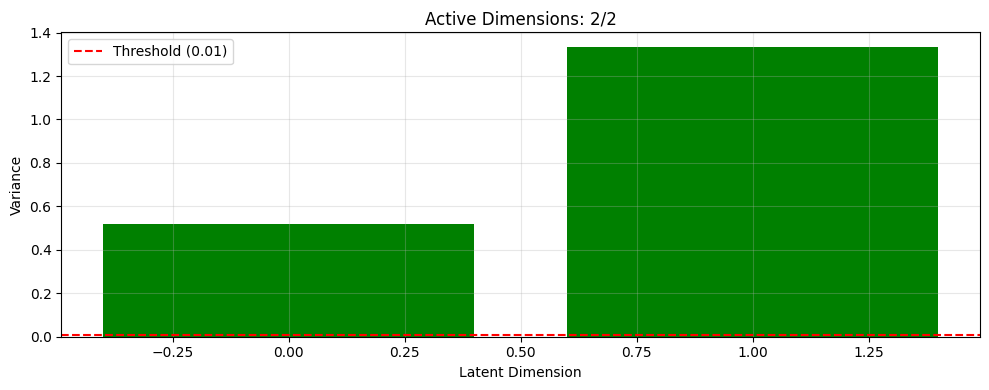

Active dimensions: 2/2
Active indices: [0, 1]
Variances: [0.5169485 1.3343863]


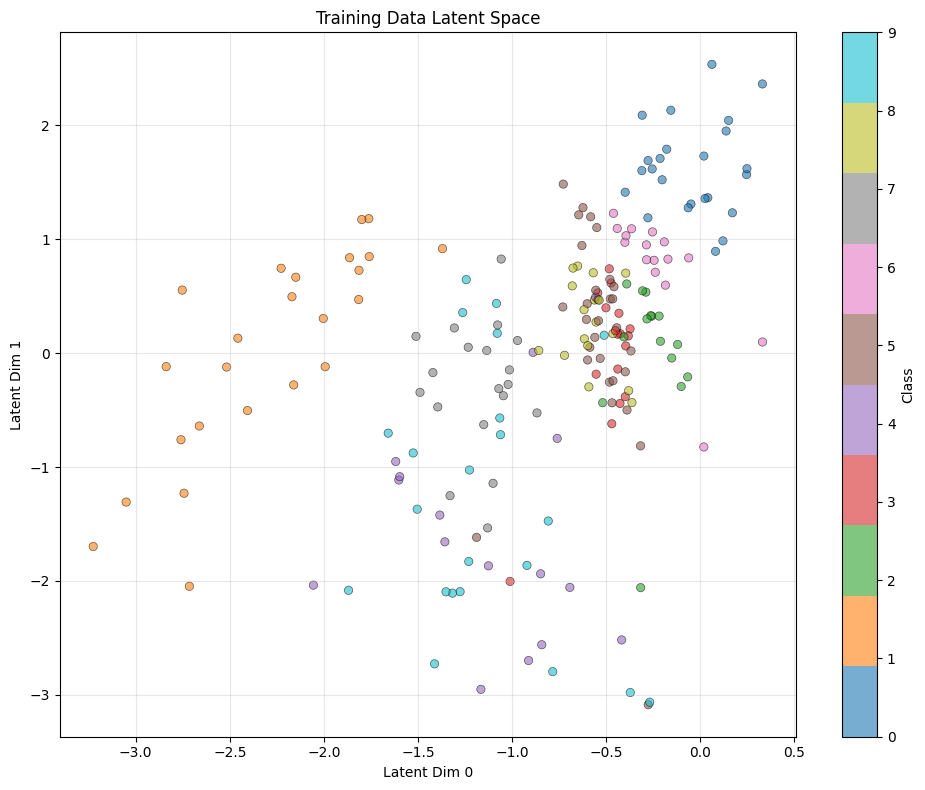

In [27]:
plot_training_curves(hist, title_prefix='VAE')

# Reusable plots for classifier training
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

# Preview reconstruction using reusable function
plot_vae_reconstructions(vae, x_train, n_examples=2, start_idx=1)

# After training your VAE, analyze it:
active_info = analyze_active_dimensions(vae, x_train, threshold=0.01)

# Visualize class separation in latent space:
z_encoded = plot_latent_space(vae, x_train, y_train, 
                               title='Training Data Latent Space',
                               method='pca')  # or 'tsne'




### Iteration 1 eval

Het basismodel met een tweedimensionale latente ruimte traint stabiel, waarbij zowel de reconstructieverlies als de totale verliesfunctie consistent dalen voor training en validatie. De KL-verlies stabiliseert na een korte opstartfase, wat erop wijst dat de latente ruimte effectief wordt geregulariseerd zonder posterior collapse. De analyse van actieve dimensies laat zien dat beide latente variabelen daadwerkelijk worden gebruikt. Ondanks deze correcte training zijn de reconstructies duidelijk wazig en blijft de classificatieprestatie beperkt, met een validatie accuracy rond 0,40 die niet boven 0,50 uitstijgt. Dit suggereert dat de latente representatie te beperkt is om zowel fijne beeldstructuren als klasseonderscheidende informatie adequaat vast te leggen.

Om deze beperking aan te pakken is mijn volgende stap het verhogen van de latent dim size. Het verhogen van de latente dimensionaliteit van 2 naar 16 vergroot de representatiecapaciteit van de VAE, waardoor het model informatie kan verdelen over meerdere latente factoren [3](Abstract"The bottleneck dimension of the VAE is a crucial design choice, and it has strong ramifications for the model’s performance, such as finding the hidden explanatory factors of a dataset using the representations learned by the VAE."). Dit is belangrijk omdat een te kleine bottleneck zoals 2 leidt tot onnauwkeurige modellering van de datadistributie en beperkte latente representaties [3](1. introduction "Studies have shown that incorrect bottleneck dimensions of DLVMs result in inaccurate modeling of the data distribution, which subsequently affects the interpretation of the latent representations produced by a DLVM."). Aangezien de intrinsieke dimensie van echte datasets onbekend is, wordt de grootte van de latente ruimte in de literatuur vaak empirisch gekozen, waarbij een startwaarde van 16 latente dimensies een gangbare en onderbouwde keuze is voor datasets zoals MNIST. Tevens is de keuze om te beginnen met 16 gebaseerd op de resultaten van onderzoeken op de hoeveelheid actieve dimensies van VAE's op de MNIST dataset. [3](Table 4)

## VAE Iterations

### Iteratie 1 (Increase latent dim 16)

In [28]:
latent_dim = 16

# Encoder
image_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="Decoder")


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

# Early stopping to allow many epochs without overfitting/leaking time
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, min_delta=1e-4, verbose=1
)

# Train VAE only on UNLABELED data; use an internal validation split
hist = vae.fit(
    x_unlabeled,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

paths = save_model_and_history(vae, hist, name='iteration1_16_dims')

Epoch 1/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - kl_loss: 2.2140 - loss: 187.5636 - reconstruction_loss: 185.3418 - val_kl_loss: 3.4778 - val_loss: 133.2174 - val_reconstruction_loss: 129.7397
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - kl_loss: 3.4944 - loss: 121.9572 - reconstruction_loss: 118.4619 - val_kl_loss: 3.4875 - val_loss: 114.4795 - val_reconstruction_loss: 110.9919
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - kl_loss: 3.4741 - loss: 111.2419 - reconstruction_loss: 107.7676 - val_kl_loss: 3.4104 - val_loss: 108.6036 - val_reconstruction_loss: 105.1929
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - kl_loss: 3.4119 - loss: 107.1148 - reconstruction_loss: 103.7019 - val_kl_loss: 3.4194 - val_loss: 105.3491 - val_reconstruction_loss: 101.9295
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - kl_loss: 3.3585 - loss: 104.4806 - reconstruction_loss: 101.1220 - val_kl_loss: 3.3147 - val_loss: 103.5076 - val_reconstruction_loss: 100.

In [30]:
loaded = load_vae_weights(vae, name='iteration1_16_dims')

# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(learning_rate=0.01),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

Loaded VAE weights from: models\iteration1_16_dims.weights.h5
Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1750 - loss: 2.4436 - val_accuracy: 0.2000 - val_loss: 2.3184
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2000 - loss: 2.3384 - val_accuracy: 0.2000 - val_loss: 2.2317
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2250 - loss: 2.2383 - val_accuracy: 0.2000 - val_loss: 2.1492
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2450 - loss: 2.1468 - val_accuracy: 0.2800 - val_loss: 2.0713
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2600 - loss: 2.0565 - val_accuracy: 0.2800 - val_loss: 1.9970
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2700 - loss: 1.9767 - val_accuracy: 0.2800 - val_loss: 1.9265
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3050 - loss: 1.8978 - val_accuracy: 0.3600 - val_loss: 1.8599
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/ste

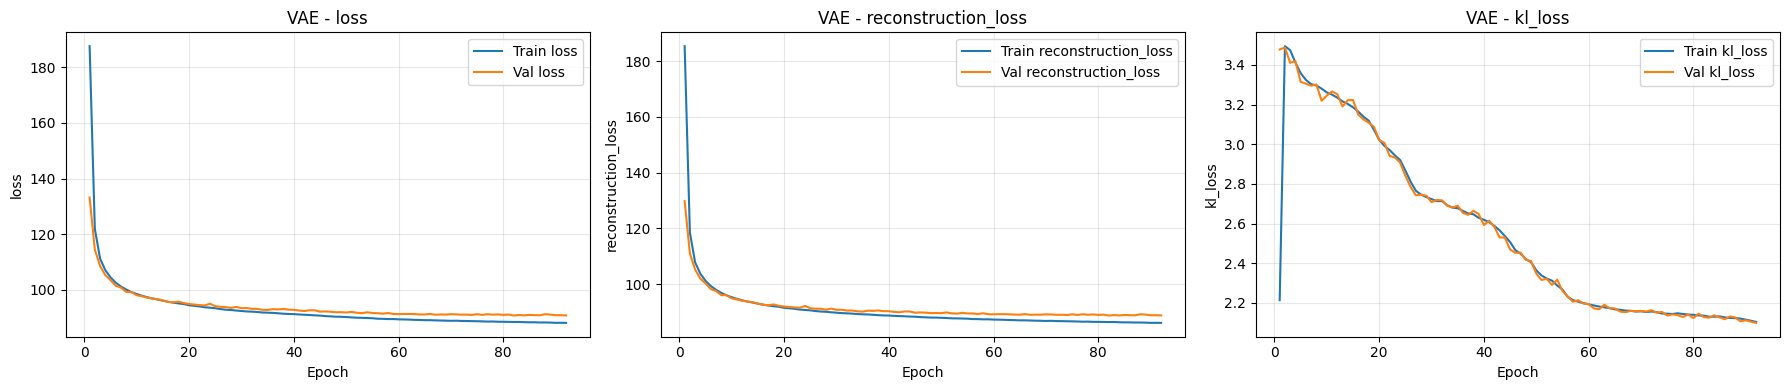

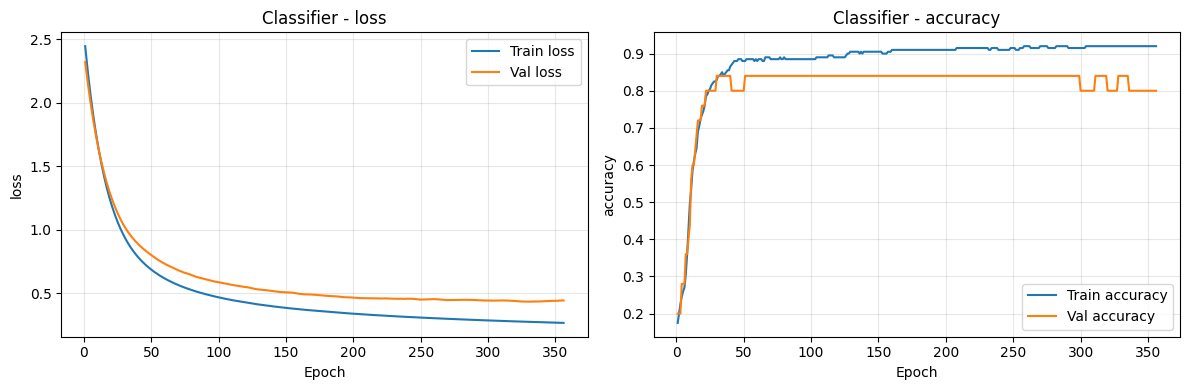

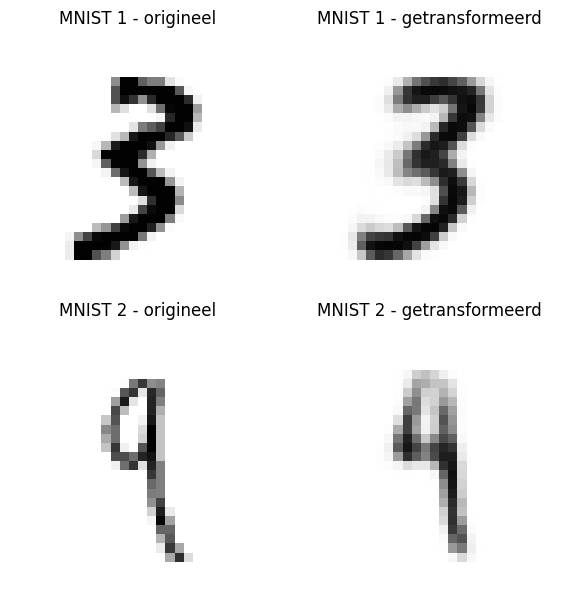

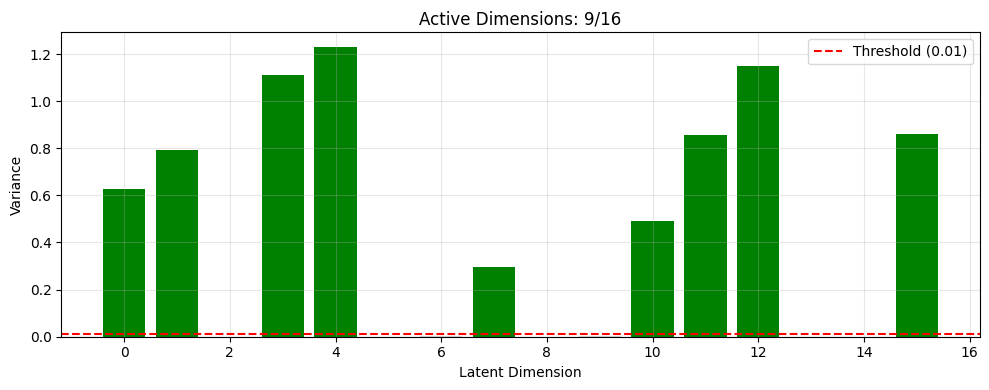

Active dimensions: 9/16
Active indices: [0, 1, 3, 4, 7, 10, 11, 12, 15]
Variances: [6.2768519e-01 7.9366666e-01 1.1867976e-04 1.1098213e+00 1.2304834e+00
 1.0985534e-04 1.1394869e-03 2.9518467e-01 9.2626309e-05 1.5893705e-03
 4.9106348e-01 8.5545784e-01 1.1473829e+00 3.8757062e-05 1.7904305e-05
 8.6121696e-01]


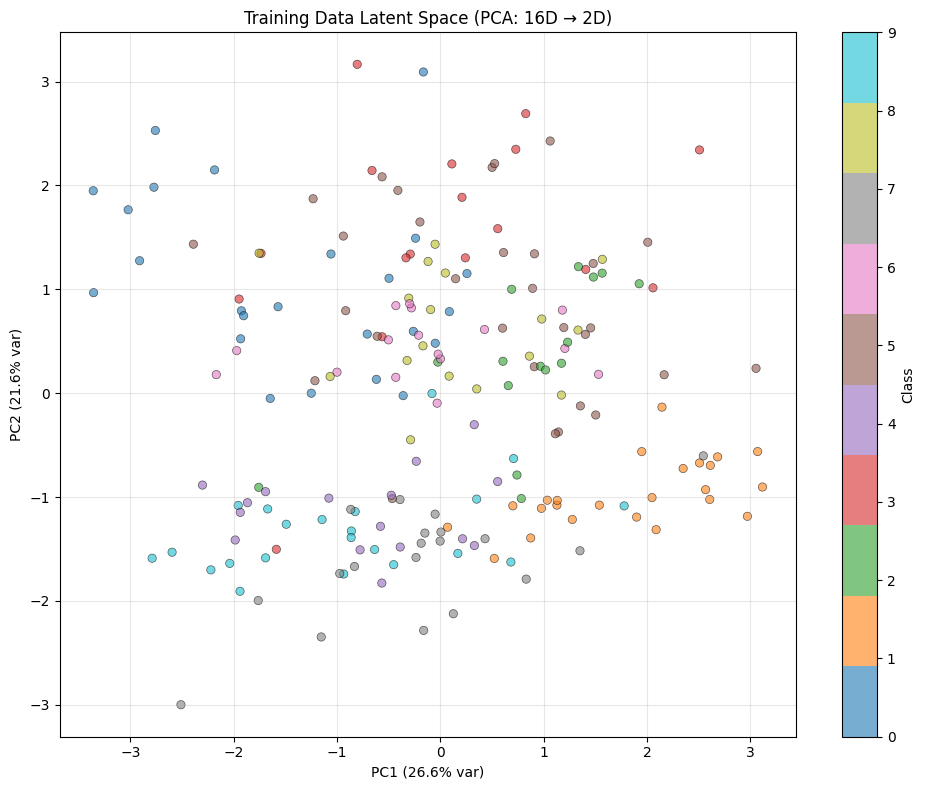

In [31]:
plot_training_curves(hist, title_prefix='VAE')

# Reusable plots for classifier training
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

# Preview reconstruction using reusable function
plot_vae_reconstructions(vae, x_train, n_examples=2, start_idx=1)

# After training your VAE, analyze it:
active_info = analyze_active_dimensions(vae, x_train, threshold=0.01)

# Visualize class separation in latent space:
z_encoded = plot_latent_space(vae, x_train, y_train, 
                               title='Training Data Latent Space',
                               method='pca')  # or 'tsne'

#### Iteration 1 eval

Bij de eerste iteratie met een latente dimensionaliteit van 16 laat het VAE duidelijk betere prestaties zien dan het basismodel. Zowel de reconstructieverlies als de totale verliesfunctie dalen substantieel verder en stabiliseren netjes voor training en validatie, wat wijst op een goed getrainde generatieve representatie. De reconstructies zijn visueel scherper en behouden meer detail, wat erop duidt dat de extra latente capaciteit effectief wordt benut. Dit wordt ondersteund door de analyse van actieve dimensies, waar 9 van de 16 latente variabelen actief zijn. Ook voor de downstream taak is een sterke verbetering zichtbaar, aangezien de classifier een validatie accuracy van ongeveer 0,80 bereikt. Dit bevestigt dat de rijkere latente representatie niet alleen de generatieve kwaliteit verbetert, maar ook meer klasseonderscheidende informatie bevat.

Omdat een groot deel van de latente dimensies actief blijft en de prestaties nog steeds stijgen, is het zinvol om verder te onderzoeken of extra latente capaciteit aanvullende voordelen kan opleveren. In de literatuur die als basis voor deze architecturale keuzes is gebruikt, wordt aangegeven dat een verdere verhoging naar 32 latente dimensies soms nog lichte verbeteringen kan geven, zelfs wanneer een deel van deze dimensies uiteindelijk inactief blijft. Daarom is in de volgende iteratie de latente dimensionaliteit verhoogd naar 32, met als doel te evalueren of extra redundante capaciteit leidt tot nog betere representaties en classificatieprestaties, of juist bevestigt waar de verzadiging van de latente ruimte optreedt. De stap grote van 16 naar 32 is gekozen op basis van de waargenomen resultaten uit [3](Table 4) 

### Iteration 2 (increase latent dim 32)

In [33]:
latent_dim = 32

# Encoder
image_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="Decoder")


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

# Early stopping to allow many epochs without overfitting/leaking time
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, min_delta=1e-4, verbose=1
)

# Train VAE only on UNLABELED data; use an internal validation split
hist = vae.fit(
    x_unlabeled,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

paths = save_model_and_history(vae, hist, name='iteration2_32_dims')

Epoch 1/100
  5/436 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - kl_loss: 0.0014 - loss: 538.1670 - reconstruction_loss: 538.1656    

c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\keras\src\backend\common\backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


436/436 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - kl_loss: 1.8758 - loss: 186.1354 - reconstruction_loss: 184.2523 - val_kl_loss: 3.1127 - val_loss: 134.3269 - val_reconstruction_loss: 131.2141
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 3.1366 - loss: 120.1044 - reconstruction_loss: 116.9661 - val_kl_loss: 3.1536 - val_loss: 112.2149 - val_reconstruction_loss: 109.0612
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - kl_loss: 3.0471 - loss: 109.6360 - reconstruction_loss: 106.5892 - val_kl_loss: 3.0040 - val_loss: 107.0455 - val_reconstruction_loss: 104.0415
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - kl_loss: 3.0232 - loss: 105.6168 - reconstruction_loss: 102.5931 - val_kl_loss: 3.0329 - val_loss: 103.7347 - val_reconstruction_loss: 100.7016
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - kl_loss: 3.0123 - loss: 103.1350 - reconstruction_loss: 100.1224 - val_kl_loss: 3.0109 - val_loss: 101.9781 - val_reconstruction_loss: 98.9670
Epoch 6/

In [36]:
loaded = load_vae_weights(vae, name='iteration2_32_dims')

# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(learning_rate=0.01),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

Loaded VAE weights from: models\iteration2_32_dims.weights.h5
Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0900 - loss: 2.5974 - val_accuracy: 0.0800 - val_loss: 2.3431
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1700 - loss: 2.4279 - val_accuracy: 0.1600 - val_loss: 2.2107
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2250 - loss: 2.2746 - val_accuracy: 0.2400 - val_loss: 2.0884
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3100 - loss: 2.1284 - val_accuracy: 0.3200 - val_loss: 1.9752
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3950 - loss: 1.9970 - val_accuracy: 0.4000 - val_loss: 1.8695
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4350 - loss: 1.8745 - val_accuracy: 0.4800 - val_loss: 1.7717
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4700 - loss: 1.7633 - val_accuracy: 0.4800 - val_loss: 1.6819
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/ste

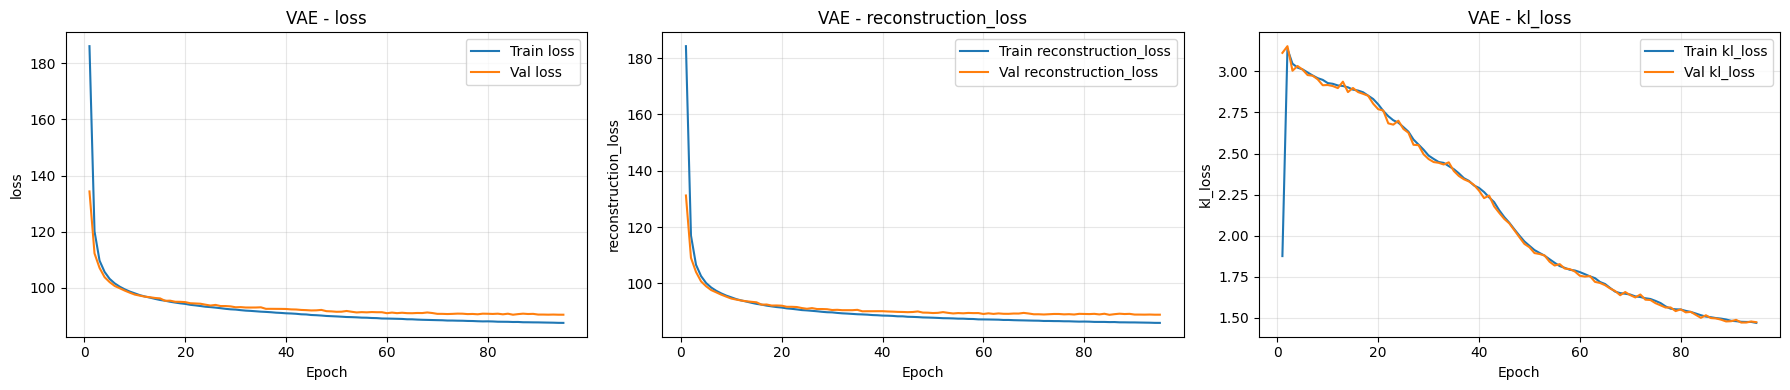

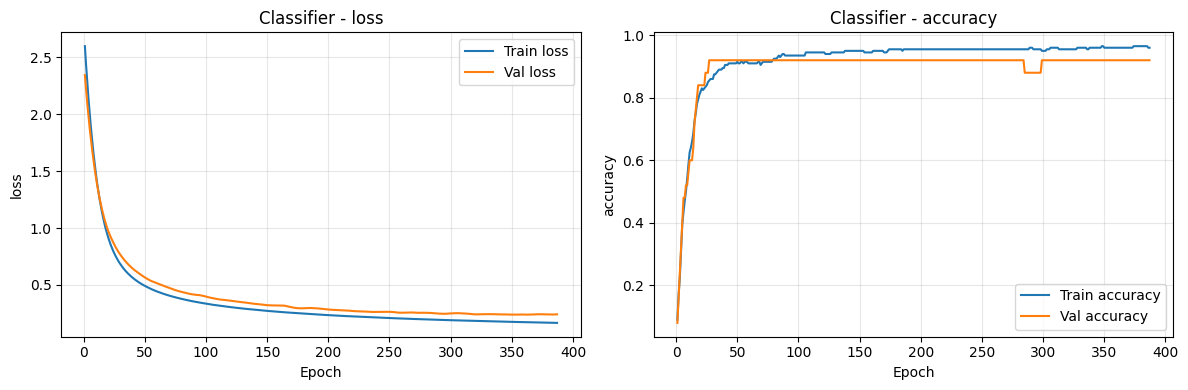

c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\keras\src\backend\common\backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


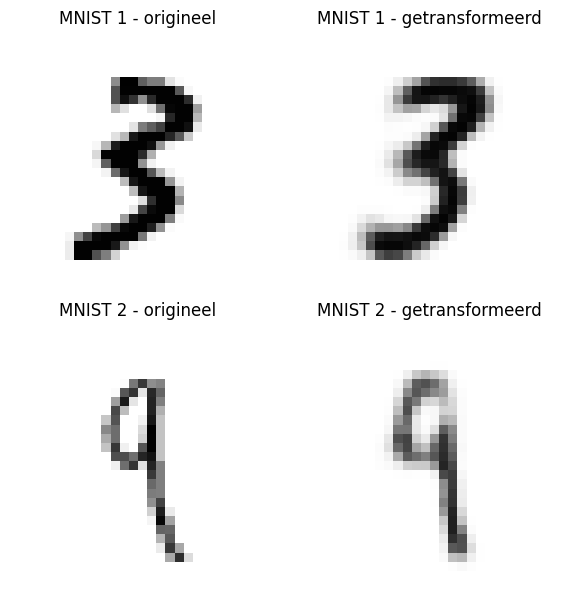

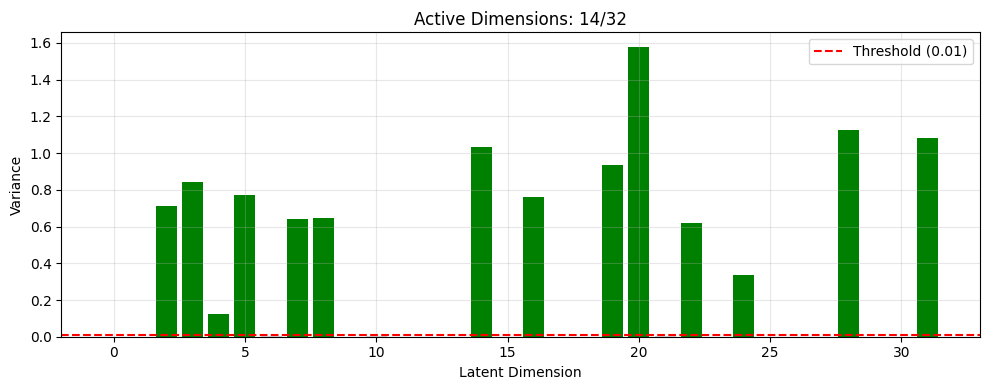

Active dimensions: 14/32
Active indices: [2, 3, 4, 5, 7, 8, 14, 16, 19, 20, 22, 24, 28, 31]
Variances: [5.50088007e-04 4.90411418e-04 7.14474499e-01 8.41257095e-01
 1.21982448e-01 7.74071217e-01 1.53540564e-03 6.42897189e-01
 6.46350920e-01 9.06292058e-04 1.81294710e-03 1.01304075e-04
 2.51894438e-04 1.04734383e-03 1.03504753e+00 7.02851568e-04
 7.63200521e-01 3.34145501e-04 1.15365998e-04 9.37888086e-01
 1.57912874e+00 1.21105392e-03 6.20802522e-01 1.01099396e-03
 3.36321175e-01 7.03642436e-04 3.30194278e-04 6.11181429e-04
 1.12371647e+00 2.54731509e-04 6.41952065e-05 1.08015478e+00]


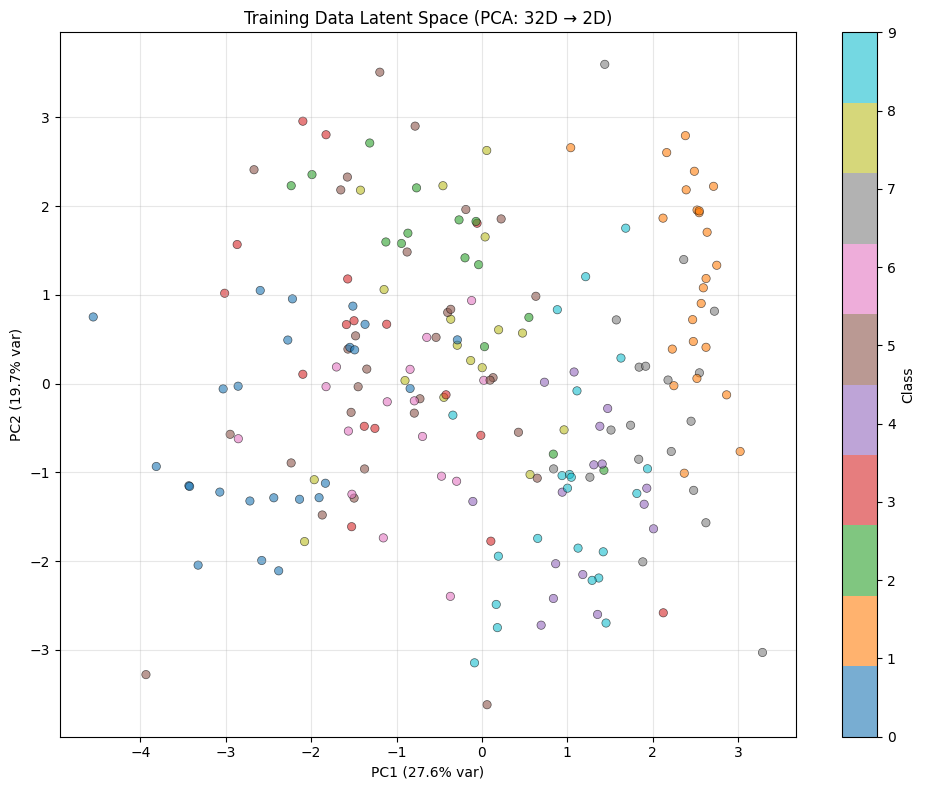

In [37]:
plot_training_curves(hist, title_prefix='VAE')

# Reusable plots for classifier training
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

# Preview reconstruction using reusable function
plot_vae_reconstructions(vae, x_train, n_examples=2, start_idx=1)


# After training your VAE, analyze it:
active_info = analyze_active_dimensions(vae, x_train, threshold=0.01)

# Visualize class separation in latent space:
z_encoded = plot_latent_space(vae, x_train, y_train, 
                               title='Training Data Latent Space',
                               method='pca')  # or 'tsne'



In iteratie 2, waarin de latente dimensionaliteit verder is verhoogd naar 32, blijft de VAE stabiel trainen en worden opnieuw lichte verbeteringen waargenomen. De reconstructieverlies en totale verlies dalen verder ten opzichte van de 16-dimensionale variant en ook de downstream classifier profiteert hiervan, met een validatie accuracy die oploopt tot ongeveer 0,92. De analyse van actieve dimensies laat zien dat 14 van de 32 dimensies actief zijn. Dit bevestigt dat extra latente capaciteit deels effectief wordt benut, maar ook dat een aanzienlijk deel redundant blijft. De winst ten opzichte van 16 dimensies is aanwezig maar beperkt, wat erop wijst dat de representatiecapaciteit begint te verzadigen.

Omdat verdere verhoging van de latente dimensionaliteit slechts marginale verbeteringen oplevert, is in de volgende iteratie gekozen voor een andere vorm van inductieve bias door het introduceren van een β-parameter in de verliesfunctie. Deze parameter balanceert expliciet de reconstructieterm en de regularisatie van de latente ruimte [4] *(Abstract: "We introduce an adjustable hyperparameter β that balances latent channel capacity and independence constraints with reconstruction accuracy")*.

Door β te verhogen wordt de capaciteit van het latente informatiekanaal sterker beperkt en wordt extra druk uitgeoefend om statistisch onafhankelijke latente factoren te leren [4] (Introduction 1: "With β > 1 the model is pushed to learn a more efficient latent representation of the data, which is disentangled if the data contains at least some underlying factors of variation that are independent” and “Varying β changes the degree of applied learning pressure during training, thus encouraging different learnt representations")*.

Deze verschuiving gaat gepaard met een bekende trade-off tussen reconstructiekwaliteit en disentanglement, waarbij scherpe reconstructies niet langer het primaire doel zijn [4] *(2 β-VAE FRAMEWORK DERIVATION: "The extra pressures coming from high β values, however, may create a trade-off between reconstruction fidelity and the quality of disentanglement within the learnt latent representations")* and [4] *(4.2 QUANTITATIVE BENCHMARKS: "Good disentangled representations often lead to blurry reconstructions due to the restricted capacity of the latent information channel z")*.

Dit sluit aan bij het uiteindelijke doel van classificatie en representatieleren, waarbij goed gescheiden latente factoren robuustere en interpreteerbare representaties opleveren [4] (3 DISENTANGLEMENT METRIC: "A representation of the data that is disentangled with respect to these generative factors, i.e. which
encodes them in separate latents, would enable robust classification even using very simple linear
classifier").

Op basis van de kwantitatieve evaluatie in de literatuur is β ingesteld op 4 [4] *(4.2 QUANTITATIVE BENCHMARKS: "It can be seen that β-VAE (β = 4) significantly outperforms all baselines")*, waarbij expliciet wordt geaccepteerd dat dit kan leiden tot iets wazigere reconstructies in ruil voor beter disentangled en taakrelevante latente representaties [4] *(4.1 QUALITATIVE BENCHMARKS: "While increasing β often leads to better disentanglement, it may come at the cost of blurrier reconstructions and losing representations for some factors, particularly those that correspond to only minor changes in pixel space")*.

### Iteration 3 (increase beta)


In [53]:
latent_dim = 32

# Encoder
image_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="Decoder")


vae = VAE(encoder, decoder, beta=4.0)
vae.compile(optimizer=keras.optimizers.Adam())

# Early stopping to allow many epochs without overfitting/leaking time
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, min_delta=1e-4, verbose=1
)

# Train VAE only on UNLABELED data; use an internal validation split
hist = vae.fit(
    x_unlabeled,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

paths = save_model_and_history(vae, hist, name='iteration3_32_dims_beta4')


Epoch 1/100
  5/436 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - kl_loss: 1.1915e-04 - loss: 540.3948 - reconstruction_loss: 540.3943

c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\keras\src\backend\common\backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - kl_loss: 0.2892 - loss: 212.6875 - reconstruction_loss: 211.5275 - val_kl_loss: 0.6248 - val_loss: 182.8996 - val_reconstruction_loss: 180.4005
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - kl_loss: 0.8219 - loss: 174.1016 - reconstruction_loss: 170.8133 - val_kl_loss: 0.8995 - val_loss: 169.1186 - val_reconstruction_loss: 165.5206
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - kl_loss: 0.8888 - loss: 166.0148 - reconstruction_loss: 162.4595 - val_kl_loss: 0.8639 - val_loss: 163.4581 - val_reconstruction_loss: 160.0020
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - kl_loss: 0.8333 - loss: 161.6573 - reconstruction_loss: 158.3241 - val_kl_loss: 0.7994 - val_loss: 159.7902 - val_reconstruction_loss: 156.5924
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 0.7741 - loss: 158.6742 - reconstruction_loss: 155.5776 - val_kl_loss: 0.7388 - val_loss: 157.6930 - val_reconstruction_loss: 154.7373
Epoch 6

In [54]:
loaded = load_vae_weights(vae, name='iteration3_32_dims_beta4')

# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(learning_rate=0.01),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

Loaded VAE weights from: models\iteration3_32_dims_beta4.weights.h5
Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1450 - loss: 2.5584 - val_accuracy: 0.1600 - val_loss: 2.5004
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1600 - loss: 2.4991 - val_accuracy: 0.1200 - val_loss: 2.4468
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1800 - loss: 2.4459 - val_accuracy: 0.1600 - val_loss: 2.3956
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1900 - loss: 2.3975 - val_accuracy: 0.1600 - val_loss: 2.3479
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2300 - loss: 2.3485 - val_accuracy: 0.2000 - val_loss: 2.3036
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2200 - loss: 2.3042 - val_accuracy: 0.2400 - val_loss: 2.2616
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2400 - loss: 2.2629 - val_accuracy: 0.2400 - val_loss: 2.2222
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33

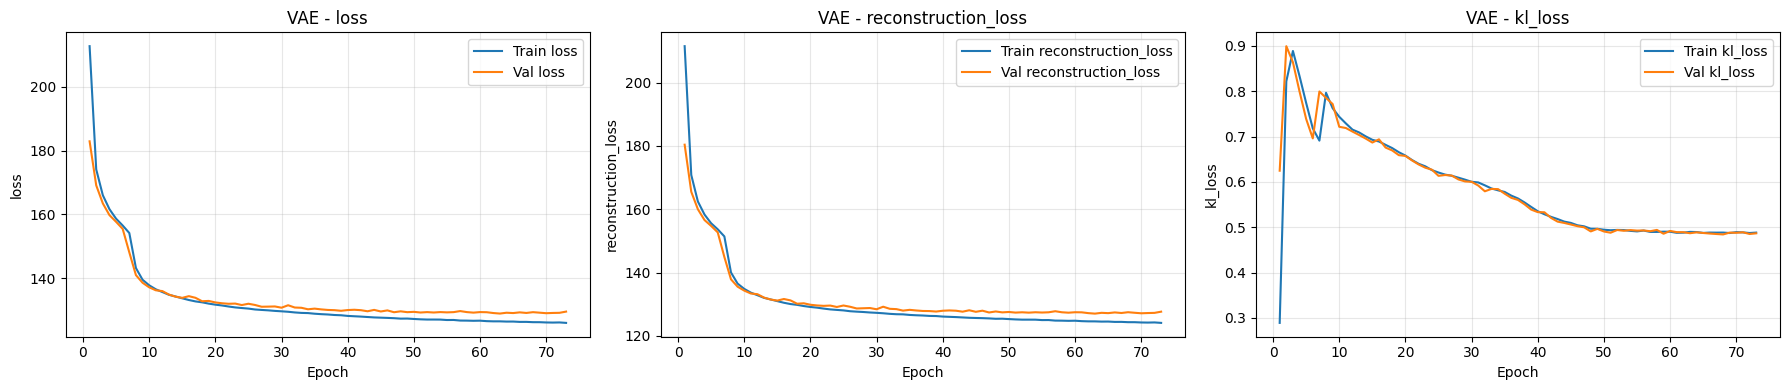

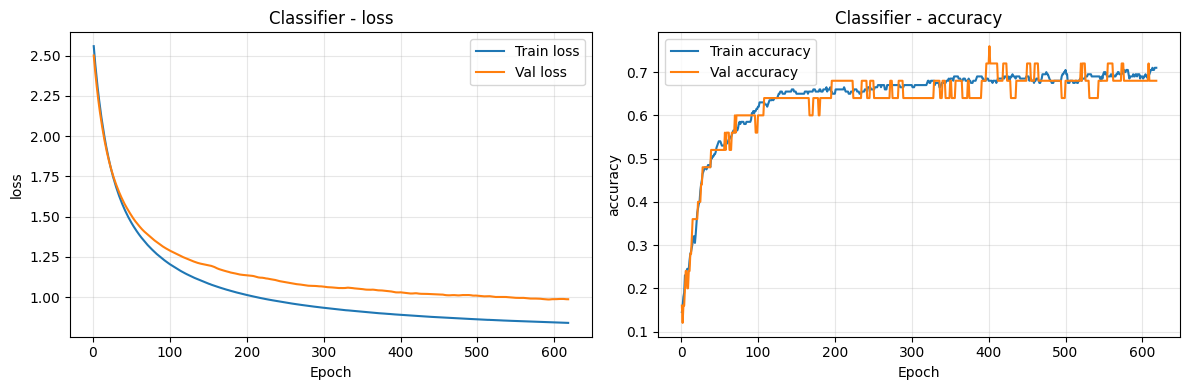

c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\keras\src\backend\common\backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


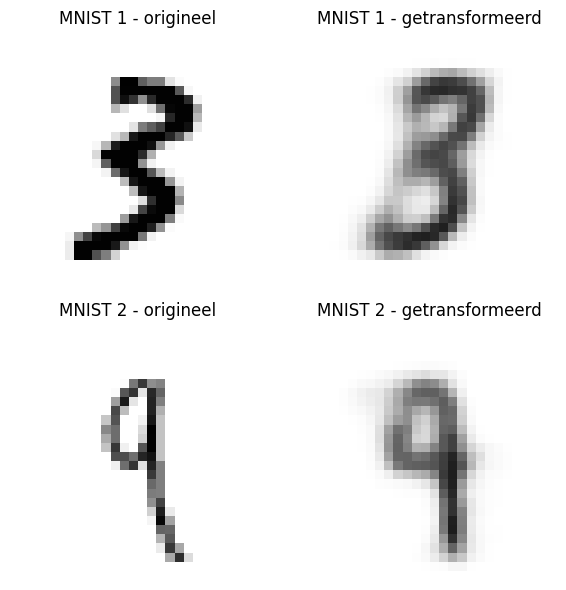

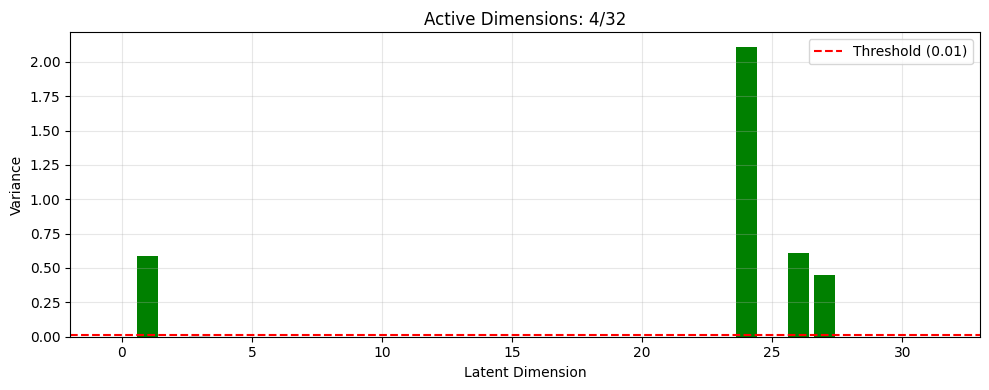

Active dimensions: 4/32
Active indices: [1, 24, 26, 27]
Variances: [4.9964210e-06 5.8396494e-01 2.4539313e-05 7.2935014e-03 8.6552072e-06
 1.3347074e-05 1.4481135e-05 1.7926468e-05 3.3545413e-05 5.9909467e-05
 1.8003984e-05 5.1005621e-04 2.7910653e-05 2.2348006e-05 4.0174582e-06
 9.6654639e-06 1.2230123e-05 8.2453807e-06 2.5544665e-05 4.1818712e-05
 3.6315654e-05 1.8219278e-05 3.5926628e-06 3.1278971e-05 2.1086097e+00
 1.3392219e-05 6.0567230e-01 4.4617236e-01 7.6304408e-05 4.9534301e-06
 1.0812901e-05 6.2009540e-06]


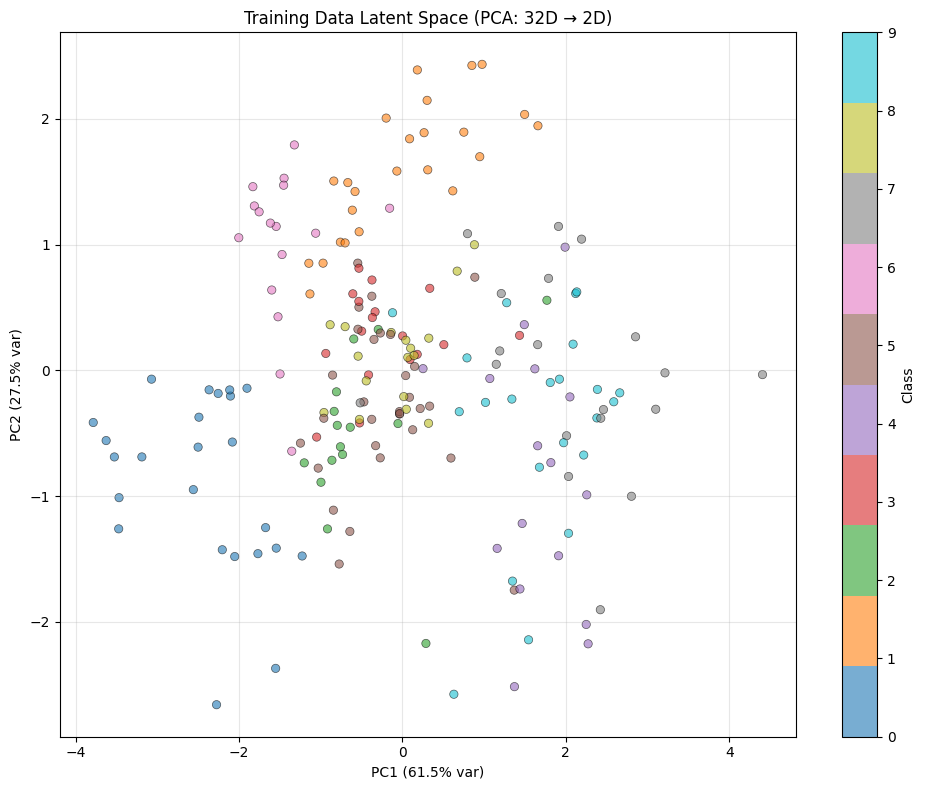

In [56]:
plot_training_curves(hist, title_prefix='VAE')

# Reusable plots for classifier training
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

# Preview reconstruction using reusable function
plot_vae_reconstructions(vae, x_train, n_examples=2, start_idx=1)


# After training your VAE, analyze it:
active_info = analyze_active_dimensions(vae, x_train, threshold=0.01)

# Visualize class separation in latent space:
z_encoded = plot_latent_space(vae, x_train, y_train, 
                               title='Training Data Latent Space',
                               method='pca')  # or 'tsne'



In iteratie 3, waarin een β-VAE met β = 4 werd gebruikt bij een latente dimensionaliteit van 32, verandert het leer­gedrag duidelijk. De KL-verlies wordt sterk onderdrukt en convergeert naar een veel lagere waarde dan in eerdere iteraties, wat aangeeft dat de latente representatie strenger wordt geregulariseerd. Dit gaat gepaard met een duidelijke afname in reconstructiekwaliteit en een lagere classificatieprestatie, waarbij de validatie accuracy daalt naar ongeveer 0,68. Daarnaast neemt het aantal actieve latente dimensies sterk af, wat erop wijst dat de combinatie van een hoge β en een grote latente ruimte leidt tot over-regularisatie, waarbij veel dimensies effectief worden uitgeschakeld. Tegelijkertijd laat de PCA-projectie zien dat de resterende actieve dimensies beter gestructureerd en beter gescheiden zijn, wat consistent is met de eerder genoemde literatuur over β-VAEs en disentanglement [4] *(4.1 QUALITATIVE BENCHMARKS: "While increasing β often leads to better disentanglement, it may come at the cost of blurrier reconstructions and losing representations for some factors, particularly those that correspond to only minor changes in pixel space")*.

Deze resultaten suggereren dat de gekozen β-waarde inderdaad de focus verschuift van reconstructie naar meer gestructureerde latente factoren, maar dat dit in combinatie met 32 dimensies te sterk is voor de downstream classificatietaak. Daarom is het logisch om in de volgende iteratie de latente dimensionaliteit terug te brengen naar 16 terwijl de β-regularisatie behouden blijft. Op deze manier wordt onderzocht of een compactere latente ruimte, gecombineerd met sterkere KL-regularisatie, een betere balans kan bieden tussen representatiestructuur en bruikbaarheid voor classificatie, zonder de overmatige capaciteitsreductie die bij 32 dimensies werd waargenomen.

### Iteration 4 (reduce dims back to 16 but keep beta=4)

In [57]:
latent_dim = 16

# Encoder
image_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(image_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
encoder = keras.Model(image_inputs, [z_mean, z_log_var], name="encoder")

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(16, activation="relu")(latent_inputs)
x = layers.Dense(7 * 7 * 64, activation="relu")(x)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="Decoder")


vae = VAE(encoder, decoder, beta=4.0)
vae.compile(optimizer=keras.optimizers.Adam())

# Early stopping to allow many epochs without overfitting/leaking time
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, min_delta=1e-4, verbose=1
)

# Train VAE only on UNLABELED data; use an internal validation split
hist = vae.fit(
    x_unlabeled,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1,
)

# Save base VAE model and history using reusable function
paths = save_model_and_history(vae, hist, name='iteration4_16_dims_beta4')

Epoch 1/100
  6/436 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - kl_loss: 0.0037 - loss: 536.6750 - reconstruction_loss: 536.6602   

c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\keras\src\backend\common\backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - kl_loss: 0.9778 - loss: 194.3804 - reconstruction_loss: 190.4608 - val_kl_loss: 2.0192 - val_loss: 140.2195 - val_reconstruction_loss: 132.1429
Epoch 2/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - kl_loss: 2.2141 - loss: 124.7236 - reconstruction_loss: 115.8662 - val_kl_loss: 2.3086 - val_loss: 116.4207 - val_reconstruction_loss: 107.1860
Epoch 3/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 2.2830 - loss: 114.1682 - reconstruction_loss: 105.0362 - val_kl_loss: 2.3371 - val_loss: 112.0861 - val_reconstruction_loss: 102.7374
Epoch 4/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - kl_loss: 2.2757 - loss: 110.3607 - reconstruction_loss: 101.2579 - val_kl_loss: 2.2501 - val_loss: 109.3659 - val_reconstruction_loss: 100.3652
Epoch 5/100
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 2.2394 - loss: 107.9464 - reconstruction_loss: 98.9886 - val_kl_loss: 2.2109 - val_loss: 106.3986 - val_reconstruction_loss: 97.5547
Epoch 6/1

In [58]:
loaded = load_vae_weights(vae, name='iteration4_16_dims_beta4')

# Freeze the encoder to keep features identical
vae.encoder.trainable = False

vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer=optimizers.Adam(learning_rate=0.01),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=25, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)

Loaded VAE weights from: models\iteration4_16_dims_beta4.weights.h5
Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0600 - loss: 2.7201 - val_accuracy: 0.1600 - val_loss: 2.5480
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0750 - loss: 2.6238 - val_accuracy: 0.1600 - val_loss: 2.4674
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1000 - loss: 2.5346 - val_accuracy: 0.1600 - val_loss: 2.3898
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1150 - loss: 2.4476 - val_accuracy: 0.1600 - val_loss: 2.3149
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1550 - loss: 2.3652 - val_accuracy: 0.2000 - val_loss: 2.2426
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1700 - loss: 2.2849 - val_accuracy: 0.2800 - val_loss: 2.1733
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2100 - loss: 2.2108 - val_accuracy: 0.2800 - val_loss: 2.1065
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34

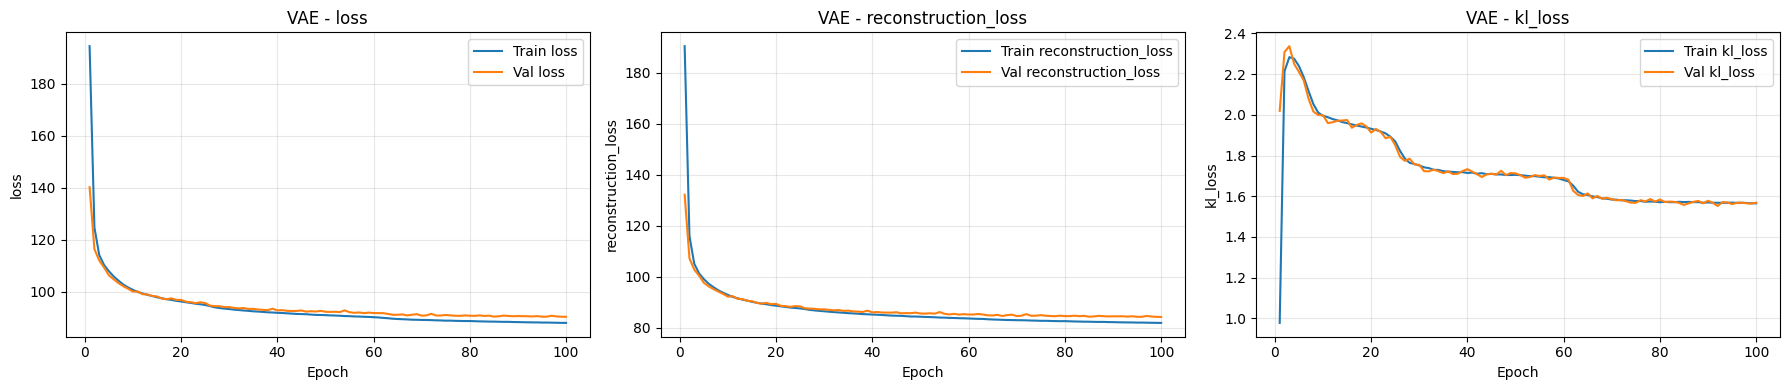

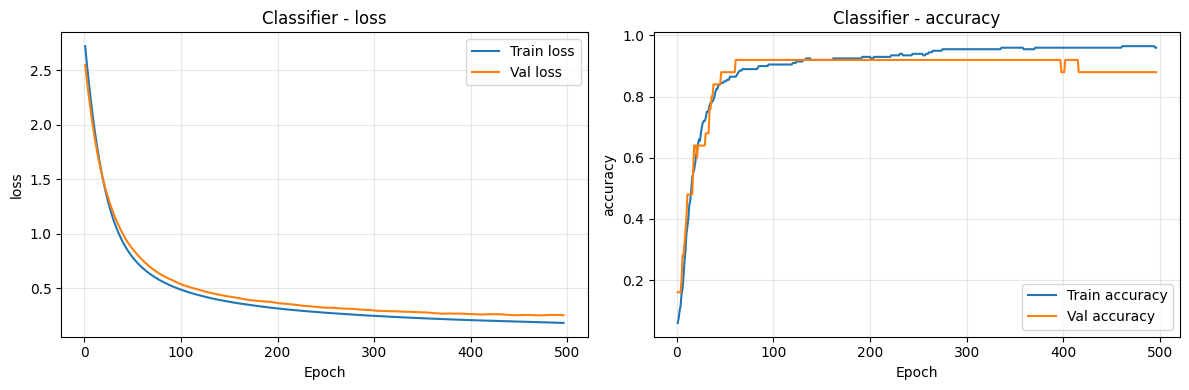

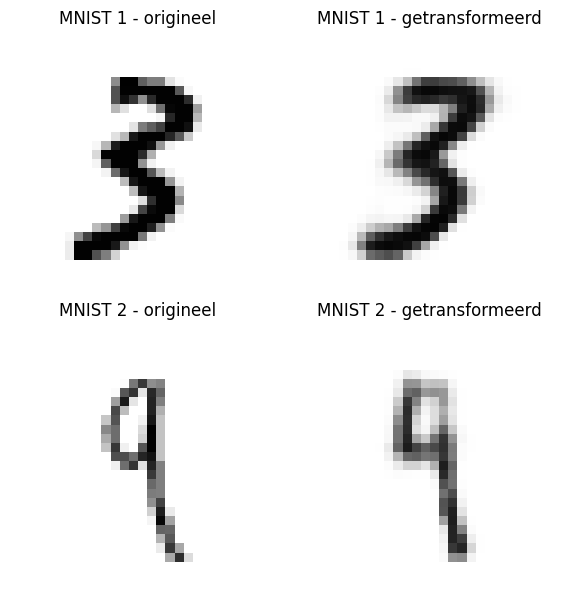

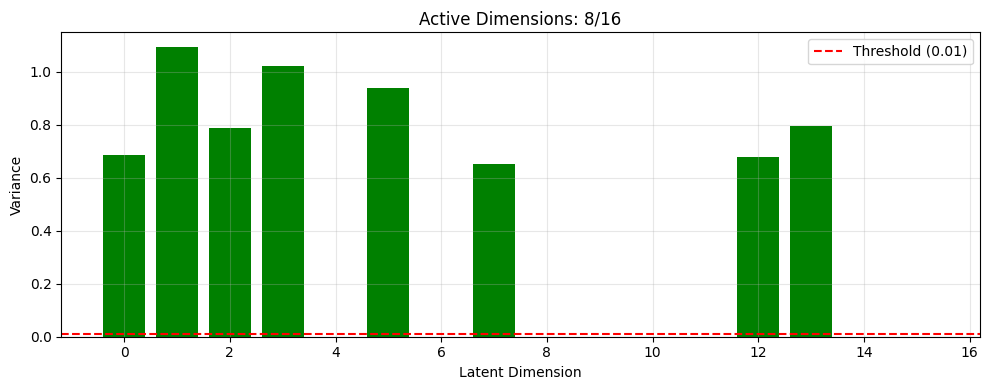

Active dimensions: 8/16
Active indices: [0, 1, 2, 3, 5, 7, 12, 13]
Variances: [6.86887562e-01 1.09379292e+00 7.85714746e-01 1.02209890e+00
 2.39971887e-05 9.39630866e-01 1.95711145e-05 6.51139855e-01
 7.99268400e-06 3.39746180e-06 2.75264338e-05 1.02660506e-05
 6.79223835e-01 7.96573639e-01 1.51706845e-05 1.63335008e-05]


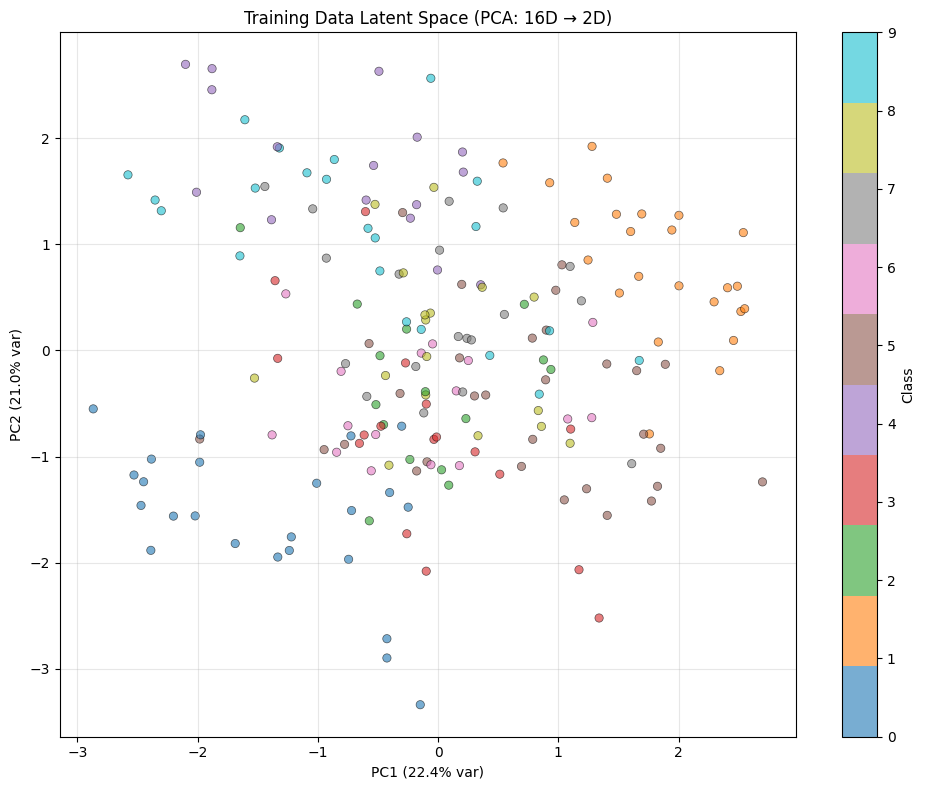

In [59]:
plot_training_curves(hist, title_prefix='VAE')

# Reusable plots for classifier training
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

# Preview reconstruction using reusable function
plot_vae_reconstructions(vae, x_train, n_examples=2, start_idx=1)


# After training your VAE, analyze it:
active_info = analyze_active_dimensions(vae, x_train, threshold=0.01)

# Visualize class separation in latent space:
z_encoded = plot_latent_space(vae, x_train, y_train, 
                               title='Training Data Latent Space',
                               method='pca')  # or 'tsne'



In iteratie 4, waarin β = 4 is behouden maar de latente dimensionaliteit is teruggebracht van 32 naar 16, ontstaat een duidelijk betere balans tussen regularisatie en bruikbare representatiecapaciteit. De VAE traint stabiel zonder dat early stopping wordt geactiveerd, wat wijst op een gelijkmatig leerproces zonder snelle overfitting. Hoewel de reconstructies iets waziger blijven dan bij β = 1, dalen de reconstructie en totale verliesfuncties consistent en blijft de KL-verlies op een gecontroleerd niveau. De analyse van actieve dimensies laat zien dat 8 van de 16 dimensies actief zijn, wat suggereert dat de beschikbare latente ruimte efficiënter wordt benut dan in de 32-dimensionale β-VAE. Daarnaast toont de PCA-projectie een duidelijkere scheiding tussen klassen wat zou moeten helpen bij de downstream classificatie.

Voor de downstream classificatie resulteert dit in een hoge trainings arruacy en een stabiele validatie arruacy rond 0,88, wat slechts beperkt onder het maximum van eerdere iteraties ligt maar met een duidelijk beter geregulariseerde latente ruimte. Hoewel verdere optimalisatie mogelijk was door extra hyperparametertuning, zoals het fijn afstellen van β of het experimenteren met tussenliggende latent dimensionaliteiten, is hier bewust van afgezien vanwege tijdsbeperkingen. De huidige latente ruimte vertoont sterke scheidbaarheid en efficiënt gebruik van dimensies, waardoor verdere aanpassingen aan de VAE-architectuur, zoals het toevoegen van extra lagen, niet noodzakelijk lijkt. De volgende en laatste stap richt zich daarom op het finetunen van de classificatiekop, aangezien de encoder nu een stabiele en taakrelevante representatie levert.

## Classifier Iterations

### Iteratie 5 tweaking learning rate

Na het afronden van de VAE-iteraties liet de classifier consistente maar trage convergentie zien, waarbij de training- en validatie- arraucy pas na honderden epochs stabiliseerden. Hoewel de uiteindelijke prestaties hoog waren, duidde het verloop van de verliescurves erop dat de optimalisatie inefficiënt verliep in de vroege trainingsfase. De latente representatie was op dat moment al stabiel en goed gestructureerd, waardoor verdere winst primair te verwachten was van betere optimalisatie van de classifier zelf, in plaats van aanpassingen aan de representatie of architectuur. Daarom is de voglende stapom de learning rate aan te passen, als minst ingrijpende en meest gerichte manier om de trainingsdynamiek te verbeteren [7] *(H3.1.1 "The initial learning rate, This is often the single most important hyperparameter and one should always make sure that it has been tuned (up to approximately a factor of 2). Typical values for a neural network with standardized inputs (or inputs mapped to the (0,1) interval) are less than 1 and greater than 10−6 but these should not be taken as strict ranges and greatly depend on the parametrization of the mode")*.

Er is gekozen voor een relatief hoge initiële learning rate van 0.005 om snellere vooruitgang in de eerste trainingsfase te forceren en de classifier snel naar een goed oplossingsgebied te sturen [7] *(H2.1 "The optimal learning rate is usually close to (by a factor of 2) the largest learning rate that does not cause divergence of the training criterion")*. 

In [83]:
loaded = load_vae_weights(vae, name='iteration4_16_dims_beta4')

vae.encoder.trainable = False

# Keep a reference if needed later
vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer = keras.optimizers.Adam(learning_rate=0.005),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=200, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1500,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)


Loaded VAE weights from: models\iteration4_16_dims_beta4.weights.h5
Epoch 1/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1350 - loss: 2.3237 - val_accuracy: 0.1200 - val_loss: 2.3441
Epoch 2/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1450 - loss: 2.2808 - val_accuracy: 0.1200 - val_loss: 2.3071
Epoch 3/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1700 - loss: 2.2382 - val_accuracy: 0.1200 - val_loss: 2.2711
Epoch 4/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1900 - loss: 2.1976 - val_accuracy: 0.1600 - val_loss: 2.2357
Epoch 5/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1900 - loss: 2.1572 - val_accuracy: 0.2400 - val_loss: 2.2009
Epoch 6/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2300 - loss: 2.1182 - val_accuracy: 0.2400 - val_loss: 2.1669
Epoch 7/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2450 - loss: 2.0799 - val_accuracy: 0.2800 - val_loss: 2.1336
Epoch 8/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29

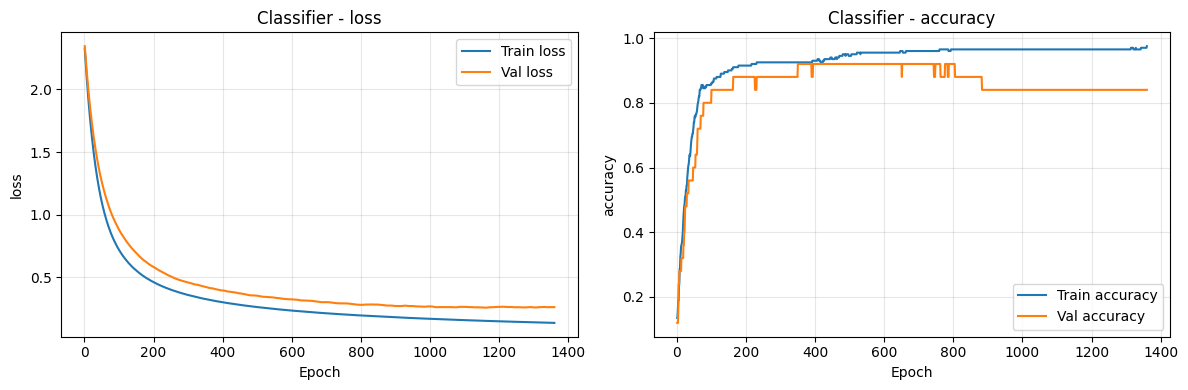

In [84]:
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

#### Iteration 5 eval

De aangepaste learning rate zorgt voor snelle en stabiele convergentie van de classifier, maar de resultaten laten een duidelijke kloof zien tussen training en validatie. Terwijl de trainings accuracy doorstijgt tot bijna 1.0, blijft de validatie accuracy zichtbaar achter en vlakt deze relatief vroeg af rond 0.85. Dit wijst erop dat het model de trainingsdata zeer goed leert, maar dat de generalisatie naar ongeziene data beperkt blijft. Om dit verschil te verkleinen zal in de volgende stap extra complexiteit worden toegevoegd in de vorm van een extra laag, gecombineerd met dropout, om te onderzoeken of dit kan helpen om training en validatie beter met elkaar in lijn te brengen.

### Iteratie 6 (extra capacity)

In [85]:
loaded = load_vae_weights(vae, name='iteration4_16_dims_beta4')

# Freeze the encoder to keep features identical
vae.encoder.trainable = False

# Keep a reference if needed later
vae_encoder = vae.encoder

# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

# Minimal added capacity before softmax
x = layers.Dense(64, activation="relu", name="vae_cls_dense")(z_mean)
cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(x)

vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer = keras.optimizers.Adam(learning_rate=0.005),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 


early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=100, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=1000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)


Loaded VAE weights from: models\iteration4_16_dims_beta4.weights.h5
Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1150 - loss: 2.2528 - val_accuracy: 0.3200 - val_loss: 2.0768
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2900 - loss: 2.0829 - val_accuracy: 0.6400 - val_loss: 1.9482
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5100 - loss: 1.9250 - val_accuracy: 0.7600 - val_loss: 1.8306
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6300 - loss: 1.7830 - val_accuracy: 0.7200 - val_loss: 1.7213
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6600 - loss: 1.6488 - val_accuracy: 0.7200 - val_loss: 1.6192
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6550 - loss: 1.5273 - val_accuracy: 0.6400 - val_loss: 1.5231
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6850 - loss: 1.4107 - val_accuracy: 0.6400 - val_loss: 1.4345
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44

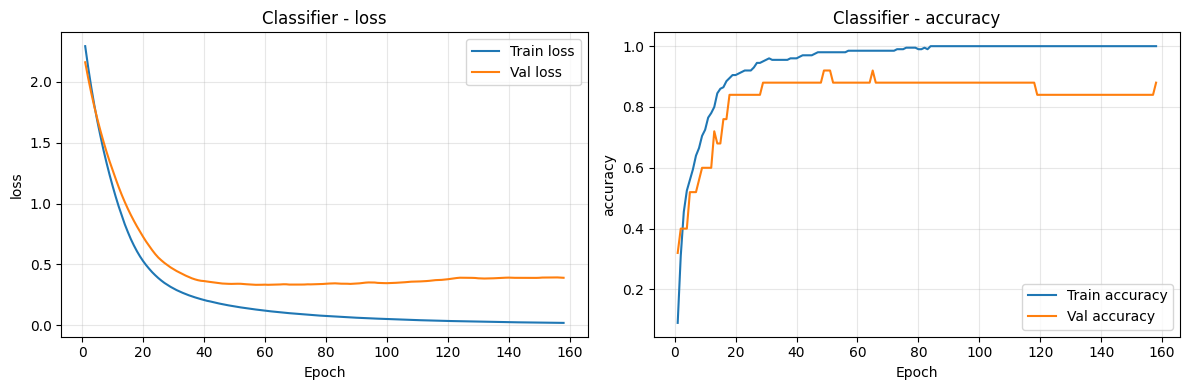

In [80]:
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

Meer complexiteit toevoegen heeft het model niet verbeterd, dit zou mogelijk kunnen komen doordat de bottleneck in het verkrijgen van meer informatie niet bij de classifier ligt maar bij de geleerde representaties van de encoder.

Daarom is de logische volgende stap om de extra layer weer weg te halen en vervolgens de encoder gedeeltelijk te unfreezen tijdens het trainen van de classifier. Hiermee kan de latente representatie zich gecontroleerd aanpassen aan de downstream objective, zonder de globale structuur die door de β-VAE is geleerd te verliezen. Deze stap richt zich direct op het verkleinen van de generalisatiekloof, zonder extra modelcomplexiteit toe te voegen.

### Iteratie 7 (Partial unfreezing of encoder layers)

In [90]:
loaded = load_vae_weights(vae, name='iteration4_16_dims_beta4')

# Freeze the encoder to keep features identical
vae.encoder.trainable = False
for layer in vae.encoder.layers[-2:]:
    layer.trainable = True

# Keep a reference if needed later
vae_encoder = vae.encoder


# Build classifier that uses z_mean as features
clf_inputs = Input(shape=(28, 28, 1), name="vae_cls_input")
z_mean, z_log_var = vae.encoder(clf_inputs)

cls_outputs = layers.Dense(10, activation="softmax", name="vae_cls_logits")(z_mean)
vae_classifier = Model(clf_inputs, cls_outputs, name="vae_based_classifier")

vae_classifier.compile(optimizer = keras.optimizers.Adam(learning_rate=0.005),
                       loss="sparse_categorical_crossentropy",
                       metrics=["accuracy"]) 

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=100, restore_best_weights=True, min_delta=1e-4, verbose=1
)

vae_cls_hist = vae_classifier.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=2000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1,
)


Loaded VAE weights from: models\iteration4_16_dims_beta4.weights.h5
Epoch 1/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1650 - loss: 2.4450 - val_accuracy: 0.1200 - val_loss: 2.2390
Epoch 2/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1400 - loss: 2.3189 - val_accuracy: 0.2000 - val_loss: 2.1589
Epoch 3/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2500 - loss: 2.2135 - val_accuracy: 0.2000 - val_loss: 2.0820
Epoch 4/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3000 - loss: 2.1173 - val_accuracy: 0.2800 - val_loss: 2.0136
Epoch 5/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3550 - loss: 2.0365 - val_accuracy: 0.3200 - val_loss: 1.9470
Epoch 6/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4050 - loss: 1.9576 - val_accuracy: 0.4400 - val_loss: 1.8813
Epoch 7/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4450 - loss: 1.8840 - val_accuracy: 0.4400 - val_loss: 1.8175
Epoch 8/2000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31

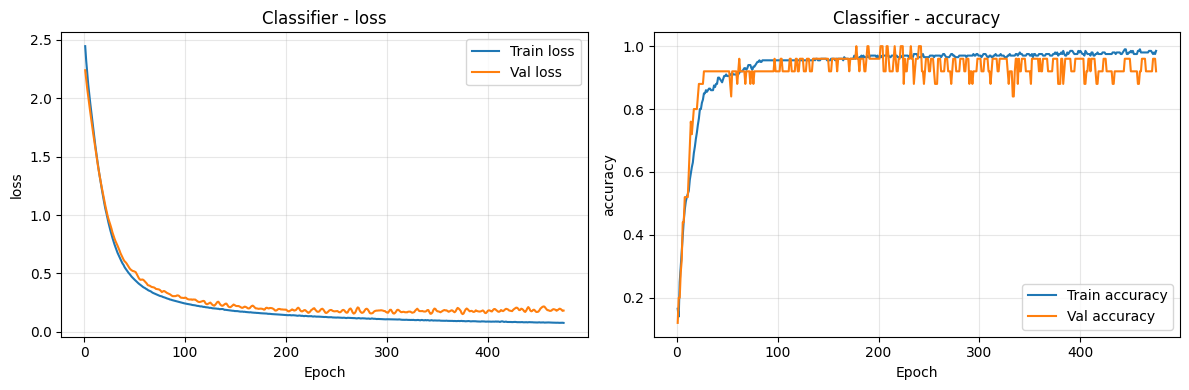

In [91]:
plot_training_curves(vae_cls_hist, title_prefix='Classifier')

#### Iteration 7 eval

Het unfreezen van de laatste twee encoderlagen zorgt ervoor dat de latente representatie zich kan aanpassen aan de classificatietaak. Dit leidt tot beter uitgelijnde training- en validatieverliezen, wat suggereert dat de encoder nu relevantere features leert voor de classifier.

De validatie accuracy wordt daarentegen wel instabiel en vertoont sterke schommelingen tussen epochs. Door de beperkte hoeveelheid validatiedata is het moeilijk om te beoordelen of deze fluctuaties echte verbeteringen weerspiegelen. Daarom is dit het eindpunt voor verdere iteraties, omdat extra aanpassingen niet betrouwbaar te evalueren zijn. Ik behoud deze iteratie wel als eind model omdat zelfs met de schommelingen dit model net iets beter scoort dan voor gaande iteraties.

In [114]:
# After training completes with early stopping
print("Training completed with early stopping")
print(f"Total epochs run: {len(vae_cls_hist.history['loss'])}")

# Find the best epoch (where validation loss was lowest)
val_losses = vae_cls_hist.history['val_loss']
best_epoch = np.argmin(val_losses) + 1  # +1 because epochs start at 1

# Get metrics from the best epoch (index is 0-based)
best_idx = best_epoch - 1
best_train_loss = vae_cls_hist.history['loss'][best_idx]
best_val_loss = vae_cls_hist.history['val_loss'][best_idx]
best_train_acc = vae_cls_hist.history['accuracy'][best_idx]
best_val_acc = vae_cls_hist.history['val_accuracy'][best_idx]

print(f"\n✓ Best weights restored from epoch {best_epoch}/{len(val_losses)}")
print(f"  Train Loss: {best_train_loss:.4f}")
print(f"  Val Loss: {best_val_loss:.4f}")
print(f"  Train Accuracy: {best_train_acc:.4f}")
print(f"  Val Accuracy: {best_val_acc:.4f}")

Training completed with early stopping
Total epochs run: 475

✓ Best weights restored from epoch 375/475
  Train Loss: 0.0923
  Val Loss: 0.1523
  Train Accuracy: 0.9800
  Val Accuracy: 0.9600


## Deel 3

Evalueer je model.

In [115]:
# Evaluate the classifier on the test set
test_loss, test_accuracy = vae_classifier.evaluate(x_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.0647
Test Accuracy: 1.0000


### Confusion matrix

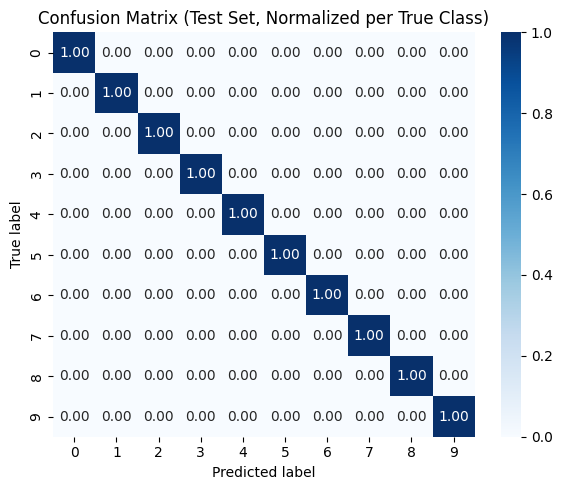

Classification Report (Test Set):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         3

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



In [116]:
# Predict on the test set
y_prob = vae_classifier.predict(x_test, verbose=0)

# Align y_true shape
y_true = y_test
if y_true.ndim > 1:
    # If one-hot encoded, convert to class indices
    y_true = np.argmax(y_true, axis=1)

# Derive class predictions
if y_prob.ndim == 1 or (y_prob.ndim == 2 and y_prob.shape[1] == 1):
    # Binary classification
    y_pred = (y_prob.ravel() >= 0.5).astype(int)
else:
    # Multiclass classification
    y_pred = np.argmax(y_prob, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Plot normalized confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Confusion Matrix (Test Set, Normalized per True Class)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

# Classification report on test set
print("Classification Report (Test Set):\n")
print(classification_report(y_true, y_pred))


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_18[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 3136)      │          0 │ conv2d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 16)        │     50,192 │ flatten_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │        272 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │        272 │ dense_27[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,552 (271.69 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 69,552 (271.69 KB)

...

 Total params: 71,152 (277.94 KB)

 Trainable params: 714 (2.79 KB)

 Non-trainable params: 69,008 (269.56 KB)

 Optimizer params: 1,430 (5.59 KB)

c:\Users\Frank\.conda\envs\testsemester2\Lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


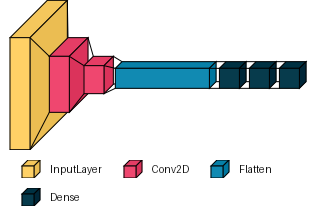

In [117]:
encoder.summary()

vae_classifier.summary()

for layer in encoder.layers:
    layer.output_shape = layer.output.shape
visualkeras.layered_view(encoder, scale_z=0.03, legend=True)



### Final eval

Het eindmodel behaalt sterke prestaties op de train-, validatie- en testset. De train accuracy bedraagt 98,0 procent en de validatie accuracy 96,0 procent, wat wijst op beperkte overfitting. De hogere validatie loss is te verklaren door de kleine hoeveelheid gelabelde data.

De test accuracy bedraagt 100 procent en alle testvoorbeelden worden correct geclassificeerd. De kant teken is dat deze accuracy niet helemaal duidelijk te intrepeteren is door de kleinze test data size van 25. De sterke schommelingen in validatie accuracy tijdens training en het feit dat de test accuracy hoger is dan de validatie accuracy lieten instabiliteit zien en hierdoor verwacht de kleine data hoeveelheid de fouten aantoont.

De VAE leert een compacte latente representatie. Van de 16 latente dimensies blijken er slechts 8 actief, wat overeenkomt met eerdere literatuur die aangeeft dat MNIST rond dit aantal latente factoren convergeert. Het verkleinen van de latente ruimte van 32 naar 16 in combinatie met een β-gewogen KL-loss droeg hier duidelijk aan bij.

De classificatiekop vereiste weinig optimalisatie, omdat de encoder al een goed scheidbare latente ruimte had geleerd. Door enkele encoderlagen te unfreezen kon het gelabelde deel van de data een beperkte maar effectieve fine-tuning uitvoeren. Voor toekomstig werk kan de latente dimensie verder worden verkleind en zou er meer gelabelde data nodig zijn om de generaliseerbaarheid beter te kunnen beoordelen.

### Requirements

#### Behaald

1. Het model gebruikt een semi-supervised leeropzet met zowel gelabelde als ongelabelde MNIST-data.
2. Een VAE is unsupervised getraind op de ongelabelde samples.
3. De encoder leert latente representaties die direct worden gebruikt voor classificatie.
4. De optimalisatie ligt primair op de latente ruimte, waarbij reconstructie een ondersteunende rol speelt.
5. De classifier maakt uitsluitend gebruik van de encoder-output en heeft geen toegang tot de ruwe input.
6. Het model is iteratief ontwikkeld, waarbij verbeteringen aan zowel VAE als classifier zijn onderbouwd en vastgelegd.
7. Alle tien MNIST-klassen worden geclassificeerd en voor geen enkele klasse ligt de accuracy onder 50 procent.
8. Het leerzwaartepunt ligt in de encoder en de classificatiekop is bewust eenvoudig gehouden.
9. De architectuurcomplexiteit is beperkt gebleven zonder extra lagen boven de afgesproken grens.
10. Het aantal trainbare parameters is beperkt en blijft dicht bij de baseline.
11. De evaluatie is uitgevoerd met gangbare kwaliteitscriteria zoals accuracy, confusion matrix en latente analyse.
12. Er is expliciet afgewogen tussen prestatieverbetering en modelcomplexiteit, waarbij extra capaciteit is vermeden.

#### Niet (volledig) behaald

13. De latente dimensie is expliciet gemotiveerd en zo ver mogelijk klein gehouden. Maar dit had nog verder verbeterd kunnen worden volgens de gevonde literatuur.
14. Het model presteert een stuk beter dan een supervised baseline, maar deze vergelijking is beperkt overtuigend door de zeer kleine validatie- en testsets, waardoor de resultaten niet helemaal betrouwbaar zijn. Ook was baseline niet helemaal eerlijk omdat de baseline een te kleine dim size had voor een goed resultaat. Een extra baseline om tegen de vergelijken zou beter geweest zijn maar heb ik niet uitgevoert vanwegen de tijd limitaties.

### Conclusie

beperkingen. Met een train accuracy van 98 procent, een validatie accuracy van 96 procent en een perfecte score op de testset wordt aangetoond dat de encoder een goed scheidbare latente ruimte heeft geleerd die direct bruikbaar is voor classificatie. De analyse van de latente ruimte bevestigt dit, aangezien slechts 8 van de 16 latente dimensies actief zijn, wat wijst op een compacte en efficiënte representatie.

Tegelijkertijd moeten deze resultaten met voorzichtigheid worden geïnterpreteerd. De zeer kleine validatie- en testsets zorgen voor instabiliteit in de validatie accuracy en maken de hoge test accuracy minder betrouwbaar. Hierdoor is de generaliseerbaarheid van het model niet overtuigend aangetoond. Desondanks onderstrepen de resultaten dat de gekozen architectuur en optimalisatie van de latente ruimte een sterke basis vormen. Hiermee is het doel van een zo goed mogelijk model gehaald voor zo ver optimalisatie mogelijk is zonder meer labeled data om tegen te valideren.


## Citations

[1] D. P. Kingma en M. Welling, Auto-Encoding Variational Bayes, Universiteit van Amsterdam, 2014. Beschikbaar op: https://arxiv.org/pdf/1312.6114

[2] J. Lucas, G. Tucker, R. Grosse en M. Norouzi, Understanding Posterior Collapse in Generative Latent Variable Models, ICLR Workshop 2019. Beschikbaar op: https://openreview.net/pdf?id=r1xaVLUYuE

[3] Saha, A., et al. ARD-VAE: A Statistical Formulation to Find the Relevant Latent Dimensions of Variational Autoencoders, 2025.
Beschikbaar via: https://pmc.ncbi.nlm.nih.gov/articles/PMC12747167/

[4] I. Higgins, L. Matthey, A. Pal, C. Burgess, X. Glorot, M. Botvinick, S. Mohamed and A. Lerchner, β-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework, Proceedings of the International Conference on Learning Representations (ICLR), 2017. Beschikbaar via: https://openreview.net/pdf?id=Sy2fzU9gl

[5] Variational Autoencoder (VAE) example, Keras. Beschikbaar via: https://keras.io/examples/generative/vae/

[6] Y. Bengio, A. Courville and P. Vincent, Representation Learning: A Review and New Perspectives, IEEE Transactions on Pattern Analysis and Machine Intelligence, vol. 35, no. 8, pp. 1798–1828, 2013. Beschikbaar via: https://arxiv.org/pdf/1206.5538

[7] Y. Bengio, Practical Recommendations for Gradient-Based Training of Deep Architectures, arXiv preprint arXiv:1206.5533, 2012. Beschikbaar via: https://arxiv.org/pdf/1206.5533